# ISM Cloud Identification — Dust Extinction, HI/CO Cubes and NenuFAR Beams

## Purpose
This notebook combines the preparation, visualisation and comparison of:

- 3D dust extinction maps (Edenhofer et al. 2023) along and around a target line of sight;
- HI and CO position–position–velocity (PPV) spectral cubes;
- NenuFAR field-of-view / beam footprints at different frequencies;
- several offset lines of sight around the primary target.

## How to adapt this notebook to your source
All source-specific parameters are grouped in **Section 1 — Configuration**.  
Edit **only that section** to point the analysis at a different target.

## Dependencies
Local modules: `spectral_tools.maps`, `spectral_tools.tools`, `spectral_tools.graphics`, `spectral_tools.reid19_rotcurve`  
Data files: `dust_map.nc`, an observation log CSV, CO and HI FITS cubes  
Python packages: `astropy`, `numpy`, `matplotlib`, `nenupy`, `scipy`, `scikit-image`, `dustmaps`


# 0. Imports and environment setup

In [1]:
%matplotlib widget

# --- Data handling ---
import numpy as np
import pandas as pd
from scipy.signal import find_peaks
import dask.array as da
import xarray as xr

# --- Graphic ---
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Circle
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from skimage import measure
import matplotlib.gridspec as gridspec

# --- Astropy ---
from astropy.coordinates import SkyCoord
from astropy.time import Time, TimeDelta
import astropy.units as u

# --- NenuFAR / nenupy ---
# from nenupy.astro.sky import Sky
from nenupy.astro.target import FixedTarget
# from nenupy.beam.hpxbeam import HpxBeam
from nenupy.instru import NenuFAR#, NenuFAR_Configuration
# from nenupy.instru.nenufar import Polarization
from nenupy.astro.pointing import Pointing
import nenupy.instru.nenufar as nenufar_core

# --- Local project modules ---
# # Install the package with: pip install -e . (from a terminal window, inside the parent file of the project)
# import spectral_tools.reid19_rotcurve as reid19_rotcurve
import spectral_tools.maps as maps
import spectral_tools.tools as tools
import spectral_tools.graphics as graphics


## Global graphics parameters

In [2]:
# Style settings for every figure of the notebooks
graphics.set_style()

# useful for mosaic plots
alphabet = 'abcdefghijklmnopqrstuvwxyz'


---
## 1. Configuration — edit this section for your source

All parameters below are the **only** values you need to change to run the notebook on a different target.  
Everything else (plots, computations, exports) adapts automatically.


In [3]:
# ============================================================
# 1a. Primary target
# ============================================================

# Human-readable name used in plot titles and file names.
SOURCE_NAME = "Tau A"

# Sky coordinates of the primary target (ICRS J2000).
# Accepted formats: sexagesimal strings (as below) or decimal degrees.
SOURCE_RA  = '05h34m31.97s'
SOURCE_DEC = '+22d00m52.1s'
CoordSource = SkyCoord(ra=SOURCE_RA, dec=SOURCE_DEC)

# Known (or estimated) distance to the source [pc].
# Used as the end-point of lines in the 3D dust visualisation.
SOURCE_DISTANCE_PC = 2000

In [4]:
# ============================================================
# 1b. Offset lines of sight
# ============================================================
# Each entry is [galactic_longitude_deg, galactic_latitude_deg].
# These are positions near the source used to probe surrounding ISM.
# Add, remove or change entries freely — the rest of the notebook
# will adapt to however many offsets you define here.
#
# Offset labels and plot colours are assigned automatically in order:
#   off_1 → blue, off_2 → green, off_3 → orange, off_4 → red, ...
# (cycle repeats for more than 4 offsets)

OFFSETS_GAL = [
    [181.90999999, -5.83000002],   # off_1
    [183.75863572, -3.75428324],   # off_2
    [183.69200623, -4.93698766],   # off_3  ← reference offset for the 3D plot
    [184.97599442, -6.13300623],   # off_4
]

# Index (0-based) of the offset used as the local reference frame
# in the 3D Cartesian conversion.  Usually the offset closest to the source.
REF_OFFSET_INDEX = 2   # → OFFSETS_GAL[2]

In [5]:
# ============================================================
# 1c. Observation log
# ============================================================
# Path to the CSV file listing your NenuFAR observations of this source.
# Expected columns: 'Année', 'Mois', 'Jour', 'Heure'
# (generated from the LT10 Source_info Google sheet).
OBSLOG_PATH = "../files/Taua-obslog.csv"

# Duration of each observation block [seconds].
OBS_DURATION_SEC = 7200

In [6]:
# ============================================================
# 1d. Spatial and spectral analysis parameters - general
# ============================================================

# Angular extent used for beam footprint / map display [deg].
SKY_EXTENSION_DEG = 5.0

# Field of view passed to the PPV cube crop routines.
FOV = (5 * u.deg, 5 * u.deg)


In [7]:
# ============================================================
# 1e. Source morphology (angular extent on the sky)
# ============================================================
# Set SOURCE_HAS_EXTENT = False for a point source or unknown morphology.
SOURCE_HAS_EXTENT = True

# Full axes of the source ellipse [arcmin] — from SIMBAD or a catalogue.
SOURCE_MAJOR_ARCMIN = 7.0   # major axis [arcmin]
SOURCE_MINOR_ARCMIN = 5.0   # minor axis [arcmin]

# Two ICRS points defining the major-axis direction (e.g. opposite corners
# of the source from SIMBAD).  Used only to compute the orientation angle
# in Galactic coordinates; see Section 2.
SOURCE_CORNER1_RA  = '05h34m43.95s'
SOURCE_CORNER1_DEC = '+21d58m59.97s'
SOURCE_CORNER2_RA  = '05h34m22.79s'
SOURCE_CORNER2_DEC = '+22d03m33.91s'

# Ellipse patch appearance on sky maps.
SOURCE_ELLIPSE_FACECOLOR = 'white'
SOURCE_ELLIPSE_EDGECOLOR = 'black'
SOURCE_ELLIPSE_LINEWIDTH = 1.5

In [8]:
# ============================================================
# 1e. Output file names
# ============================================================
FIG_FMT = ".pdf"
FIG_DIR = "../figures/"

# OUT_DUST3D  = f"dust3D_{SOURCE_NAME.replace(' ','_')}.png"      ## This plot should be saved in PNG format (too long to vectorize)
# OUT_DUSTLOS = f"dust-LoS_{SOURCE_NAME.replace(' ','_')}." + FIG_FMT
# OUT_CO_BEAMS  = f"CO-beams_{SOURCE_NAME.replace(' ','_')}." + FIG_FMT
# OUT_HI_BEAMS  = f"HI-beams_{SOURCE_NAME.replace(' ','_')}." + FIG_FMT
# OUT_CO_MOMENTS  = f"CO-moments_{SOURCE_NAME.replace(' ','_')}." + FIG_FMT
# OUT_HI_MOMENTS  = f"HI-moments_{SOURCE_NAME.replace(' ','_')}." + FIG_FMT


---
## 2. Derived coordinates

Build `SkyCoord` objects and Galactic-frame values for all offsets.
These variables are referenced throughout the notebook.

In [9]:
# Galactic coordinates of the primary source.
source_l = CoordSource.galactic.l   # Galactic longitude (Quantity, deg)
source_b = CoordSource.galactic.b   # Galactic latitude  (Quantity, deg)

# Reference offset used as the coordinate origin in the 3D dust plot.
ref_off = OFFSETS_GAL[REF_OFFSET_INDEX]

# Build SkyCoord objects for every offset position.
CoordsOff = [
    SkyCoord(l=off[0], b=off[1], unit="deg", frame="galactic")
    for off in OFFSETS_GAL
]

# Colour palette for offset lines of sight (cycles if more than 4 offsets).
_BASE_COLORS = ["blue", "green", "orange", "red",
                "purple", "brown", "pink", "cyan"]
colors = [_BASE_COLORS[i % len(_BASE_COLORS)] for i in range(len(OFFSETS_GAL))]


# ------------------------------------------------------------------
# Source morphology: position angle in Galactic coordinates
# ------------------------------------------------------------------
# arctan2(Δl, Δb) between the two corner points gives the tilt of the
# major axis in the (l, b) plane — the angle expected by Ellipse.

if SOURCE_HAS_EXTENT:
    _corner1 = SkyCoord(ra=SOURCE_CORNER1_RA, dec=SOURCE_CORNER1_DEC)
    _corner2 = SkyCoord(ra=SOURCE_CORNER2_RA, dec=SOURCE_CORNER2_DEC)

    # Longitude and latitude offsets between the two reference points.
    _dl = _corner2.galactic.l.value - _corner1.galactic.l.value
    _db = _corner2.galactic.b.value - _corner1.galactic.b.value
    SOURCE_ANGLE_DEG = np.degrees(np.arctan2(_dl, _db))

    # Convert full axes from arcmin to degrees for the Ellipse patch.
    _major_deg = SOURCE_MAJOR_ARCMIN / 60.0
    _minor_deg = SOURCE_MINOR_ARCMIN / 60.0

    print(f"Source ellipse — major: {SOURCE_MAJOR_ARCMIN:.1f}', "
          f"minor: {SOURCE_MINOR_ARCMIN:.1f}', "
          f"angle: {SOURCE_ANGLE_DEG:.2f}° (Galactic frame)")
else:
    SOURCE_ANGLE_DEG = 0.0
    _major_deg = _minor_deg = 0.0
    print("Source extent disabled — no ellipse will be drawn.")


print(f"Source '{SOURCE_NAME}':  l = {source_l:.4f},  b = {source_b:.4f}")
for i, (coord, off) in enumerate(zip(CoordsOff, OFFSETS_GAL)):
    print(f"  off_{i+1}  l={off[0]:.4f}°  b={off[1]:.4f}°   colour={colors[i]}")


Source ellipse — major: 7.0', minor: 5.0', angle: -104.61° (Galactic frame)
Source 'Tau A':  l = 184.5575 deg,  b = -5.7843 deg
  off_1  l=181.9100°  b=-5.8300°   colour=blue
  off_2  l=183.7586°  b=-3.7543°   colour=green
  off_3  l=183.6920°  b=-4.9370°   colour=orange
  off_4  l=184.9760°  b=-6.1330°   colour=red


---
## 3. Observation log and NenuFAR beam tracking

Load the observation timestamps and simulate the NenuFAR pointing for beam visualisation.

In [10]:
# Read the observation log CSV.
# Expected columns: 'Année' (year), 'Mois' (month), 'Jour' (day), 'Heure' (time HH:MM:SS).
obslog = pd.read_csv(OBSLOG_PATH)

# Build ISO-format timestamp strings for astropy.Time.
timestamps = [
    f"{row['Année']}-{row['Mois']}-{row['Jour']} {row['Heure']}"
    for _, row in obslog.iterrows()
]
obs_times = Time(timestamps)

# Observation block duration (TimeDelta object).
dt = TimeDelta(OBS_DURATION_SEC, format="sec")

# Simulate NenuFAR target-tracking pointing for the source.
targ = FixedTarget.from_name(SOURCE_NAME)
target_tracking = Pointing.target_tracking(
    target=targ,
    time=obs_times,
    duration=dt
)

print(f"Loaded {len(obs_times)} observation timestamps for '{SOURCE_NAME}'.")

Loaded 42 observation timestamps for 'Tau A'.


In [11]:
### Simulation of the beam of the instrument
mas_to_use = [f"MA00{i}" for i in range(10)] + [f'MA0{i}' for i in range(10,80)]
nenufar_core = NenuFAR()[mas_to_use]

### NenuFAR frequencies for beam-size visualisation [MHz]. Regularly spaced beam == 1/regularly spaced frequencies
BEAM_FREQUENCIES_MHZ = 1/np.linspace(1/85,0.1,9) * u.MHz
BEAM_ANGULAR_RES     = nenufar_core.angular_resolution(frequency=BEAM_FREQUENCIES_MHZ).value

### Projection of the ellipsoid beams in the sky. We take the mean beam over polarisation and time
EVERYBEAM = maps.compute_beams([CoordSource.galactic] + CoordsOff, SKY_EXTENSION_DEG, obs_times, BEAM_FREQUENCIES_MHZ, target_tracking)

---
## 4. Dust extinction profiles

Query the Edenhofer et al. (2023) 3-D dust map along the line of sight to the source
and to each offset position.  The result is a 1-D extinction profile as a function of
heliocentric distance.

In [12]:
# ============================================================
# Spatial and spectral analysis parameters - dust
# ============================================================
# Distance range for dust extinction profiles [kpc].
DUST_R_MIN, DUST_R_MAX, DUST_DR = 0.03, 2.0, 0.01

# Angular resolution of the spatial grid used for extinction profiles [deg].
DUST_DELTA_DEG = 0.1 * u.deg

# Resolution of the spatial grid used for 3D plots [pc].
# The spatial extent of the grid was computed as to include the largest beam of NenuFAR
DUST_X_MIN, DUST_X_MAX, DUST_DX = 40, 1990, 5
DUST_Y_MIN, DUST_Y_MAX, DUST_DY = -105, 106, 5
DUST_Z_MIN, DUST_Z_MAX, DUST_DZ = -105, 106, 5

# Distance axis used for extinction profiles [kpc, as a plain array].
radiitot = np.arange(DUST_R_MIN, DUST_R_MAX, DUST_DR)   # shape (n_radii,)


In [13]:
# Initialise the dust map interpolator (lazy — loads on first query).
# If the map has never been downloaded, run: maps.DustMap.fetch()
dustmap = maps.DustMap()


Configuration file not found:

    /home/cros/.dustmapsrc

To create a new configuration file in the default location, run the following python code:

    from dustmaps.config import config
    config.reset()

Note that this will delete your configuration! For example, if you have specified a data directory, then dustmaps will forget about its location.


Optimizing map for querying (this might take a couple of seconds)...


In [14]:
# Compute the spatially-averaged extinction profile towards the primary source.
# fov and delta define the angular averaging window around the line of sight.
fov_dust = (SKY_EXTENSION_DEG * u.deg, SKY_EXTENSION_DEG * u.deg)

EXTINC_source_los = dustmap.extinction_los(
    CoordSource,
    fov=fov_dust,
    delta=DUST_DELTA_DEG,
    r_min=DUST_R_MIN,
    r_max=DUST_R_MAX,
    dr=DUST_DR
)
# EXTINC_source_los: 1-D array, shape (n_radii,), same length as radiitot.

# Also compute profiles for each offset line of sight.
EXTINC_offs_los = []
for i, coord in enumerate(CoordsOff):
    ext = dustmap.extinction_los(
        coord,
        fov=fov_dust,
        delta=DUST_DELTA_DEG,
        r_min=DUST_R_MIN,
        r_max=DUST_R_MAX,
        dr=DUST_DR
    )
    EXTINC_offs_los.append(ext)
    print(f"off_{i+1} done — peak extinction at {radiitot[np.argmax(ext)]:.2f} kpc")


Dust extinction (LOS): 100%|█████████████████| 197/197 [00:00<00:00, 612.33it/s]


off_1 done — peak extinction at 0.20 kpc


Dust extinction (LOS): 100%|█████████████████| 197/197 [00:00<00:00, 625.27it/s]


off_2 done — peak extinction at 0.20 kpc


Dust extinction (LOS): 100%|█████████████████| 197/197 [00:00<00:00, 620.37it/s]


off_3 done — peak extinction at 0.20 kpc


Dust extinction (LOS): 100%|█████████████████| 197/197 [00:00<00:00, 626.39it/s]

off_4 done — peak extinction at 0.20 kpc


---
### 4a. 3D dust visualisation

Build a 3-D isosurface of the dust density around the source using the marching-cubes
algorithm, then overlay the lines of sight in Galactic Cartesian coordinates.

In [13]:
# Build a 3-D dust density cube in Galactic Cartesian coordinates [pc].
# The grid is defined in (x, y, z) pc; each point is converted back to
# (l, b, r) to query the dust map, so the marching-cubes output is already
# in pc on all three axes.
#
# Cartesian frame: Sun at origin, x toward the source, y transverse, z toward Galactic north.
# gal_to_cartesian handles the anµgular offsets from the reference direction.
#
# Grid resolution: decrease the step sizes for finer detail (slower).

# 1-D axes of the Cartesian grid.
x_arr = np.arange(DUST_X_MIN, DUST_X_MAX, DUST_DX)  # radial distance [pc]
y_arr = np.arange(DUST_Y_MIN, DUST_Y_MAX, DUST_DY) # transverse [pc]
z_arr = np.arange(DUST_Z_MIN, DUST_Z_MAX, DUST_DZ) # vertical   [pc]

# 3-D meshgrid of Cartesian coordinates.
x_grid, y_grid, z_grid = np.meshgrid(x_arr, y_arr, z_arr, indexing='ij')

# Convert each Cartesian point to Galactic (l, b, r) for the dust query.
# Galactic longitude and latitude from Cartesian offsets.
l_center, b_center = ref_off[0], ref_off[1]
l_grid, b_grid, r_grid = tools.cartesian_to_galactic(x_grid, y_grid, z_grid, l_center, b_center)


# Query the dust map; fill invalid voxels with 0.
values = np.zeros_like(r_grid)
coords_all = SkyCoord(
    l=l_grid * u.deg,
    b=b_grid * u.deg,
    frame='galactic',
    distance=r_grid * u.pc
)
shell = dustmap._query.query(coords_all)
values = np.where(np.isnan(shell), 0.0, shell)

# Voxel sizes for marching_cubes (uniform grid).
dx, dy, dz = DUST_DX, DUST_DY, DUST_DZ
x0, y0, z0 = x_arr[0], y_arr[0], z_arr[0]


In [14]:
# -----------------------------------------------------------------
# Isosurface extraction using the marching-cubes algorithm.
# The threshold is set to 1 % of the peak density — adjust if needed.
# -----------------------------------------------------------------
threshold = np.max(values) / 100
print(f"Isosurface threshold: {threshold:.5g}")

verts, faces, normals, vals = measure.marching_cubes(
    values,
    level=threshold,
    spacing=(dx, dy, dz)
)
# Shift vertices back to physical (Galactic) coordinates.
verts[:, 0] += x0
verts[:, 1] += y0
verts[:, 2] += z0



Isosurface threshold: 0.00054577


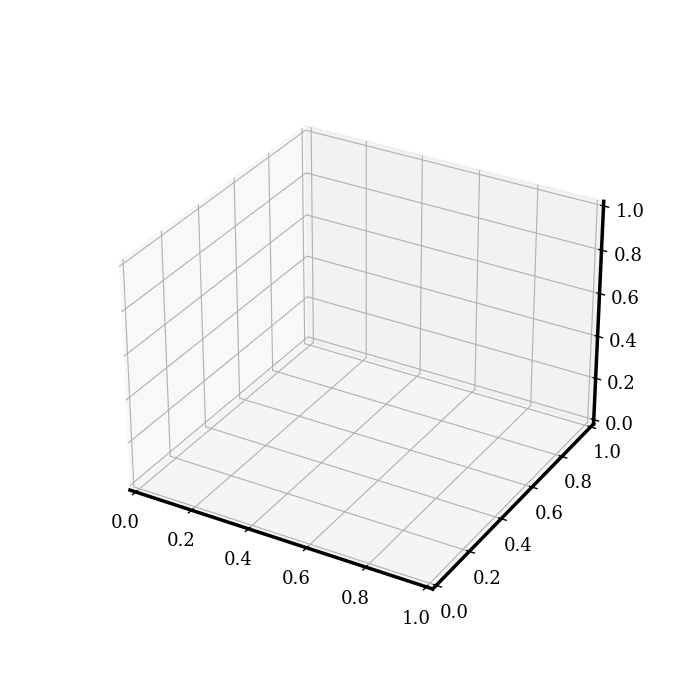

In [15]:
# -----------------------------------------------------------------
# 3-D plot: isosurface + lines of sight.
# -----------------------------------------------------------------
figdust = plt.figure(figsize=(7, 7))
ax3d = figdust.add_subplot(projection='3d')


In [16]:
ax3d.clear()

# Draw the dust isosurface as a semi-transparent mesh.
mesh = Poly3DCollection(verts[faces], alpha=0.4, linewidths=0.05, color='lightgray')
ax3d.add_collection3d(mesh)

# Axis limits from the grid extent.
ax3d.set_xlim(x_arr.min(), x_arr.max())   # distance   [pc]
ax3d.set_ylim(y_arr.min(), y_arr.max())   # transverse [pc] 
ax3d.set_zlim(z_arr.min(), z_arr.max())   # vertical   [pc] 

ax3d.set_yticklabels([])
ax3d.set_zticklabels([])
ax3d.set_xlabel("Heliocentric distance (pc)", labelpad=25)
ax3d.set_title(f"Dust clouds towards {SOURCE_NAME}")

# Draw lines of sight from the Sun (origin) to SOURCE_DISTANCE_PC for each offset.
for i, off in enumerate(OFFSETS_GAL):
    xc, yc, zc = tools.galactic_to_cartesian(SOURCE_DISTANCE_PC,  
                                   off[0], off[1],
                                   ref_off[0], ref_off[1])
    ax3d.plot([0, xc], [0, yc], [0, zc], c=colors[i], ls='dotted',
              label=f"off_{i+1}")

# Primary source line of sight: solid black dashed line.
xc, yc, zc = tools.galactic_to_cartesian(SOURCE_DISTANCE_PC,
                               source_l.value, source_b.value,
                               ref_off[0], ref_off[1])
ax3d.plot([0, xc], [0, yc], [0, zc], c='black', ls='dashed', label=SOURCE_NAME)
ax3d.legend(fontsize=8)

ax3d.set_box_aspect(((x_arr.max() - x_arr.min())/2, y_arr.max() - y_arr.min(), z_arr.max() - z_arr.min()))



Saved: dust3D_Tau_A.png


In [ ]:
figdust.savefig(OUT_DUST3D, bbox_inches='tight')
print(f"Saved: {OUT_DUST3D}")

---
### 4b. Cloud path-length estimation from dust profiles

Identify extinction peaks in the line-of-sight profile and measure their
full-width-at-half-maximum (FWHM) as an estimate of each cloud's depth.

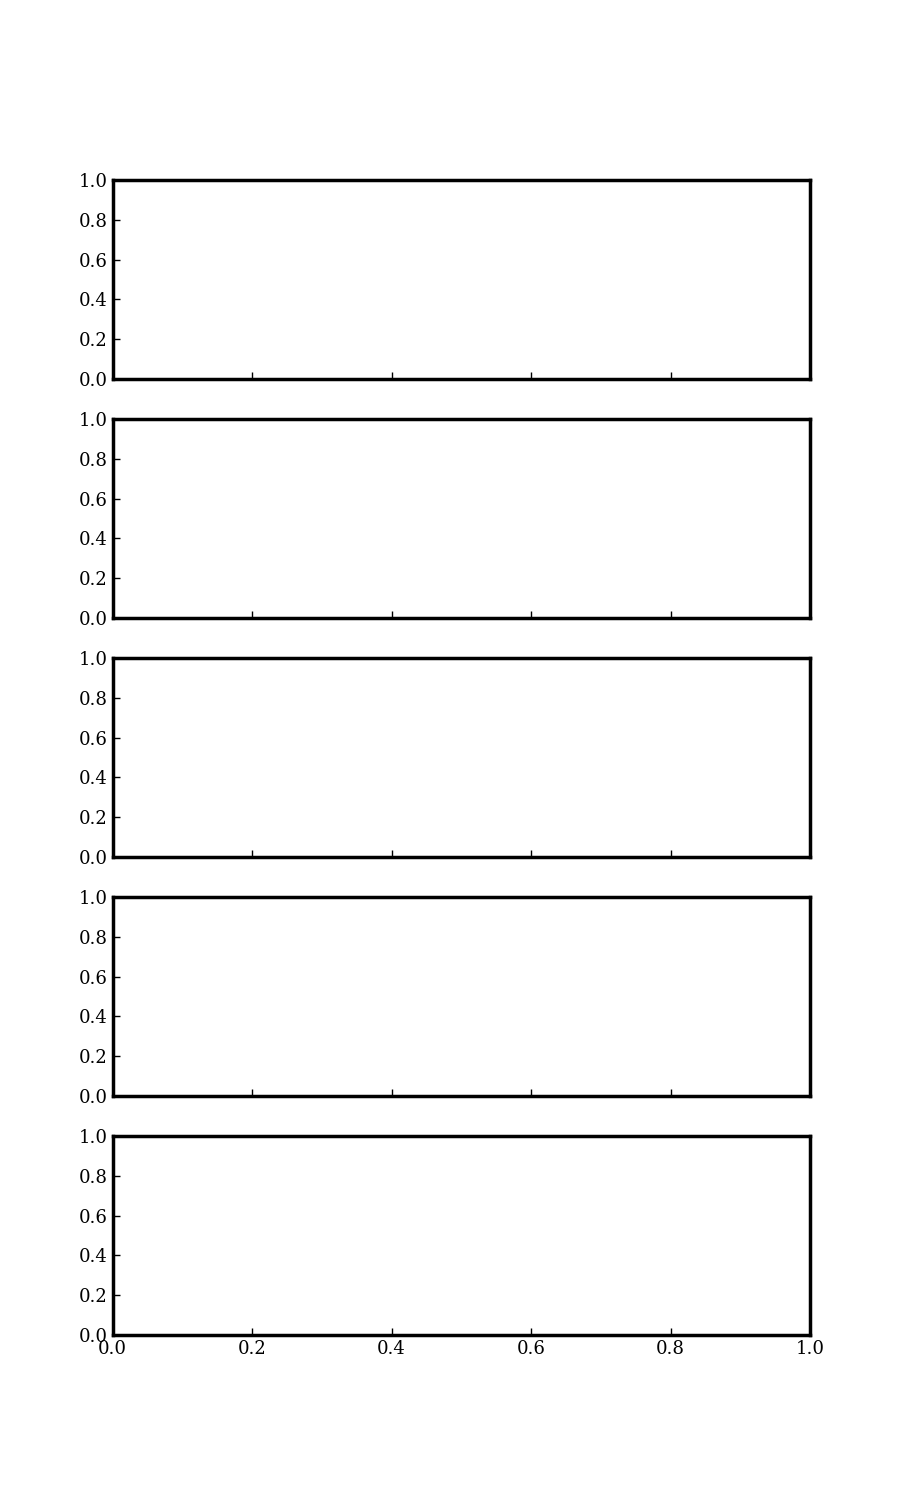

In [13]:
n_panels = 1 + len(OFFSETS_GAL)   # source + one panel per offset
fig_peaks, axes_peaks = plt.subplots(
    n_panels, 1,
    figsize=(9, 3 * n_panels),
    sharex=True
)
if n_panels == 1:
    axes_peaks = [axes_peaks]


In [14]:

# Normalised source extinction profile — used as reference in offset panels.
r_norm = EXTINC_source_los / np.nanmax(EXTINC_source_los)

CLOUD_LEVEL = 0.5 # full width x % max of the peak

for ax in axes_peaks :
    ax.clear()

# --- Panel 0: primary source ---
ax0 = axes_peaks[0]
ax0.plot(radiitot, r_norm, c='black', lw=1.5)
dustmap.get_length_clouds(
    # EXTINC_source_los,
    r_norm,
    r_min=DUST_R_MIN,
    r_max=DUST_R_MAX,
    level=CLOUD_LEVEL,
    ax=ax0,
    colors=['black'],
)
ax0.set_ylabel("Normalised extinction", fontsize=11)
ax0.set_title(f"{SOURCE_NAME} — line of sight", fontsize=11)
ax0.set_ylim(-0.05, 1.3)
graphics.set_axes(ax0)

# --- Panels 1…N: offset lines of sight ---
for k, (ext_off, col) in enumerate(zip(EXTINC_offs_los, colors)):
    ax = axes_peaks[k + 1]
    norm_off = ext_off / np.nanmax(ext_off)

    # Source profile as a gray dashed reference.
    ax.plot(radiitot, r_norm, c='gray', lw=1.0, ls='dashed',
            label=f"{SOURCE_NAME} (ref)")

    # Offset profile with cloud annotations.
    ax.plot(radiitot, norm_off, c=col, lw=1.5)
    dustmap.get_length_clouds(
        # ext_off,
        norm_off,
        r_min=DUST_R_MIN,
        r_max=DUST_R_MAX,
        level=CLOUD_LEVEL,
        ax=ax,
        colors=[col],
    )

    off = OFFSETS_GAL[k]
    ax.set_ylabel("Normalised extinction", fontsize=11)
    ax.set_title(
        f"off_{k+1}  (l = {off[0]:.2f}°,  b = {off[1]:.2f}°)",
        fontsize=11
    )
    ax.set_ylim(-0.05, 1.3)
    ax.legend(fontsize=8, loc='upper right')
    graphics.set_axes(ax)

axes_peaks[-1].set_xlabel("Distance from the Sun (kpc)", fontsize=12)
pct_str = f"FW{round(CLOUD_LEVEL * 100):.0f}M"
fig_peaks.suptitle(
    f"Dust extinction peaks — {SOURCE_NAME}  ({pct_str}, level = {CLOUD_LEVEL})",
    fontsize=13, y=1.01
)
fig_peaks.tight_layout()

In [31]:
fig_peaks.savefig(OUT_DUSTLOS, bbox_inches='tight')
print(f"Saved: {OUT_DUSTLOS}")

Saved: dust-LoS_Tau_A.pdf


---
### 4c. Summary table of dust in lines-of-sights

Summarise dust distribution in the different beams based on the dust absorption.
Provides an estimate of the distance of the clouds, as well as their depth based on the FWHM of the absorption.

In [15]:
# Estimate cloud path lengths for the primary source line of sight.
# Optional keyword arguments let you flag noisy peaks or force Gaussian fitting:
#   flags=[k]         — skip peak index k
#   large_peaks=[k]   — double the search radius for peak k
#   small_peaks=[k]   — halve the search radius for peak k
#   fit_gaussian=True — use Gaussian fitting instead of direct FWHM
#   level = x/100     — compute the full width at x % of the maximum of the peak. Default = 0.5

los_names = ["TauA","off1","off2","off3","off4"]

peak_idx, peak_dist, path_lengths = dustmap.get_length_clouds(
    EXTINC_source_los,
    r_min=DUST_R_MIN * 1000,   # convert kpc → pc for the distance axis
    r_max=DUST_R_MAX * 1000,
    level = 0.5
)

indices_list = [peak_idx]
distances_list = [peak_dist]
sizes_list = [path_lengths]
print(f"Detected {len(peak_idx)} dust cloud(s) towards {SOURCE_NAME}:")
for i, (d, pl) in enumerate(zip(peak_dist, path_lengths)):
    print(f"  Cloud {i+1}: distance = {d:.0f} pc,  path length ≈ {pl:.0f} pc")

for i,sourcename in enumerate(["off1","off2","off3","off4"]) :
    peak_idx, peak_dist, path_lengths = dustmap.get_length_clouds(
        EXTINC_offs_los[i],
        r_min=DUST_R_MIN * 1000,   # convert kpc → pc for the distance axis
        r_max=DUST_R_MAX * 1000,
        level = 0.5
    )

    indices_list.append(peak_idx)
    distances_list.append(peak_dist)
    sizes_list.append(path_lengths)
    print(f"Detected {len(peak_idx)} dust cloud(s) towards {sourcename}:")
    for i, (d, pl) in enumerate(zip(peak_dist, path_lengths)):
        print(f"  Cloud {i+1}: distance = {d:.0f} pc,  path length ≈ {pl:.0f} pc")


Detected 9 dust cloud(s) towards Tau A:
  Cloud 1: distance = 60 pc,  path length ≈ 34 pc
  Cloud 2: distance = 161 pc,  path length ≈ 7 pc
  Cloud 3: distance = 201 pc,  path length ≈ 18 pc
  Cloud 4: distance = 392 pc,  path length ≈ 55 pc
  Cloud 5: distance = 553 pc,  path length ≈ 65 pc
  Cloud 6: distance = 734 pc,  path length ≈ 52 pc
  Cloud 7: distance = 1105 pc,  path length ≈ 67 pc
  Cloud 8: distance = 1357 pc,  path length ≈ 68 pc
  Cloud 9: distance = 1588 pc,  path length ≈ 114 pc
Detected 6 dust cloud(s) towards off1:
  Cloud 1: distance = 201 pc,  path length ≈ 18 pc
  Cloud 2: distance = 392 pc,  path length ≈ 55 pc
  Cloud 3: distance = 533 pc,  path length ≈ 78 pc
  Cloud 4: distance = 734 pc,  path length ≈ 56 pc
  Cloud 5: distance = 1105 pc,  path length ≈ 64 pc
  Cloud 6: distance = 1588 pc,  path length ≈ 194 pc
Detected 9 dust cloud(s) towards off2:
  Cloud 1: distance = 60 pc,  path length ≈ 33 pc
  Cloud 2: distance = 201 pc,  path length ≈ 22 pc
  Cloud 3: 

In [17]:
#  SUMMARY OF ALL CLOUDS PRESENT ALONG THE LINES OF SIGHT
# Two clouds are considered the same if their distances agree within `tol`
 
TOL = 30  # pc — adjust to your data

allclouds_list = [
    list(zip(distances, sizes))
    for distances, sizes in zip(distances_list, sizes_list)
]

group_reps, all_entries = tools.find_all_groups(keys = los_names, 
                                                values_list = allclouds_list, 
                                                tol=TOL)

sorted_groups = sorted(enumerate(group_reps), key=lambda x: x[1])
rank = {old_i: new_i for new_i, (old_i, _) in enumerate(sorted_groups)}
group_reps_sorted = [r for _, r in sorted_groups]
all_entries = [(los, rank[g], dist, size) for los, g, dist, size in all_entries]
 
n_groups = len(group_reps_sorted)
cloud_labels = [f"Cloud {i+1} ({int(r)} pc)" for i, r in enumerate(group_reps_sorted)]

# ── Presence matrix ───────────────────────────────────────────────────────────
# Cells show the cloud size; empty = absent
 
matrix = pd.DataFrame(
    index   = cloud_labels,
    columns = los_names,
    data    = "",
    dtype   = object,
)
matrix.index.name = "Cloud (distance) \\ Pointing"
 
for los, g, dist, size in all_entries:
    matrix.loc[cloud_labels[g], los] = round(size)
 
display(
    matrix.style.set_caption(
        "Cloud depth (pc) per line of sight"
    )
)



,TauA,off1,off2,off3,off4
Cloud (distance) \ Pointing,,,,,
Cloud 1 (60 pc),34,,33,,33
Cloud 2 (160 pc),7,,,,8
Cloud 3 (200 pc),18,18,22,18,18
Cloud 4 (391 pc),55,55,,62,47
Cloud 5 (421 pc),,,44,,
Cloud 6 (522 pc),,,66,70,
Cloud 7 (552 pc),65,78,,,40
Cloud 8 (733 pc),52,56,56,50,54
Cloud 9 (1105 pc),67,64,62,69,67


---
## 5. HI spectral cube — extraction and moment maps

Load the HI 21-cm PPV cube, crop it around the source, compute the mean spectrum
and moment maps, then compare them to the dust profile and NenuFAR beams.

In [25]:
# ============================================================
# Spatial and spectral analysis parameters - HI
# ============================================================
# Velocity range to highlight in HI spectra [km/s].
VMIN_HI, VMAX_HI = -30, 20
# Selection along the dust line of sight (kpc)
RMIN_HI, RMAX_HI = 0.03, 2

# Graphic parameters
HI_color = "red"
HI_cmap = "Reds"

In [26]:
# ============================================================
# Spatial and spectral analysis parameters - CO à bouger
# ============================================================
# Velocity range to highlight in CO spectra [km/s].
VMIN_CO, VMAX_CO = -10, 15
# Selection along the dust line of sight (kpc)
RMIN_HI, RMAX_HI = 0.03, 2

# Graphic parameters
CO_color = "blue"
CO_cmap = "Blues"

In [27]:
# Initialise the map loader for the current source.
# The loader finds the HI and CO FITS cubes by matching SOURCE_NAME
# against the file names in the data directories.
# Adjust path_co and path_hi if your cubes live elsewhere.
map_loader = maps.MapLoader(
    source=SOURCE_NAME.replace(" ", ""),   # e.g. "TauA" — must match FITS file names
    path_co="../maps/COmaps/",
    path_hi="../maps/HImaps/"
)


In [28]:
# Crop the HI cube to the field of view defined in Section 1.
# Returns:
#   SLICEHI      — cropped PPV sub-cube (3-D array)
#   velHI        — velocity axis [km/s]
#   spectrumHI   — mean spectrum over the aperture [K]
#   lonslice_HI  — Galactic longitude axis of the cropped region [deg]
#   latslice_HI  — Galactic latitude axis [deg]
#   mom0_HI      — moment-0 map (integrated intensity) over the full velocity range

SLICEHI, velHI, spectrumHI, lonslice_HI, latslice_HI, mom0_HI = \
    map_loader.crop_square(CoordSource, 'HI', FOV)

print(f"HI cube cropped: {SLICEHI.shape},  vel range [{velHI.min():.1f}, {velHI.max():.1f}] km/s")


HI cube cropped: (155, 60, 60),  vel range [-99.1, 99.3] km/s


In [29]:
# Compute the moment-0 map restricted to the velocity range [VMIN_HI, VMAX_HI].
# This isolates emission likely associated with ISM clouds along the line of sight.

_, velHI_full, spectrumHI_full, lonHI_full, latHI_full, mom0_HI_vel = \
    map_loader.moment0_crop(
        CoordSource, 'HI', FOV,
        v_start=VMIN_HI, v_stop=VMAX_HI,
        shape="square"
    )

# Velocity condition mask — used later for coloured spectrum segments.
condHI = (velHI >= VMIN_HI) & (velHI <= VMAX_HI)


### 5a. Mosaic channel map
Displays HI brightness temperature in 25 velocity channels arranged in a 5×5 grid.  
Each panel covers a 2 km/s wide velocity slice.  

In [31]:
# ── Configuration ─────────────────────────────────────────────────────────────

SHAPE     = "square"
EXTEN     = SKY_EXTENSION_DEG        # angular size of each cutout

VMIN_CHAN = VMIN_HI                  # lowest velocity edge (km/s)
VMAX_CHAN = VMAX_HI                  # highest velocity edge (km/s)
N_PANELS  =  25                  # number of panels in the channel map (i.e. resolution of the channel map)

VMIN_NORM = 0                   # colormap minimum (normalised T_b)
VMAX_NORM = np.nanmax(SLICEHI)  # colormap maximum (normalised T_b)

SHOW_BEAM    = False            # overlay the beam FWHM circle
SHOW_OFFBEAM = True             # overlay the off-beam pointing

center_l = source_l   # change to an offset if you want 
center_b = source_b   # to center the chanel map elsewhere

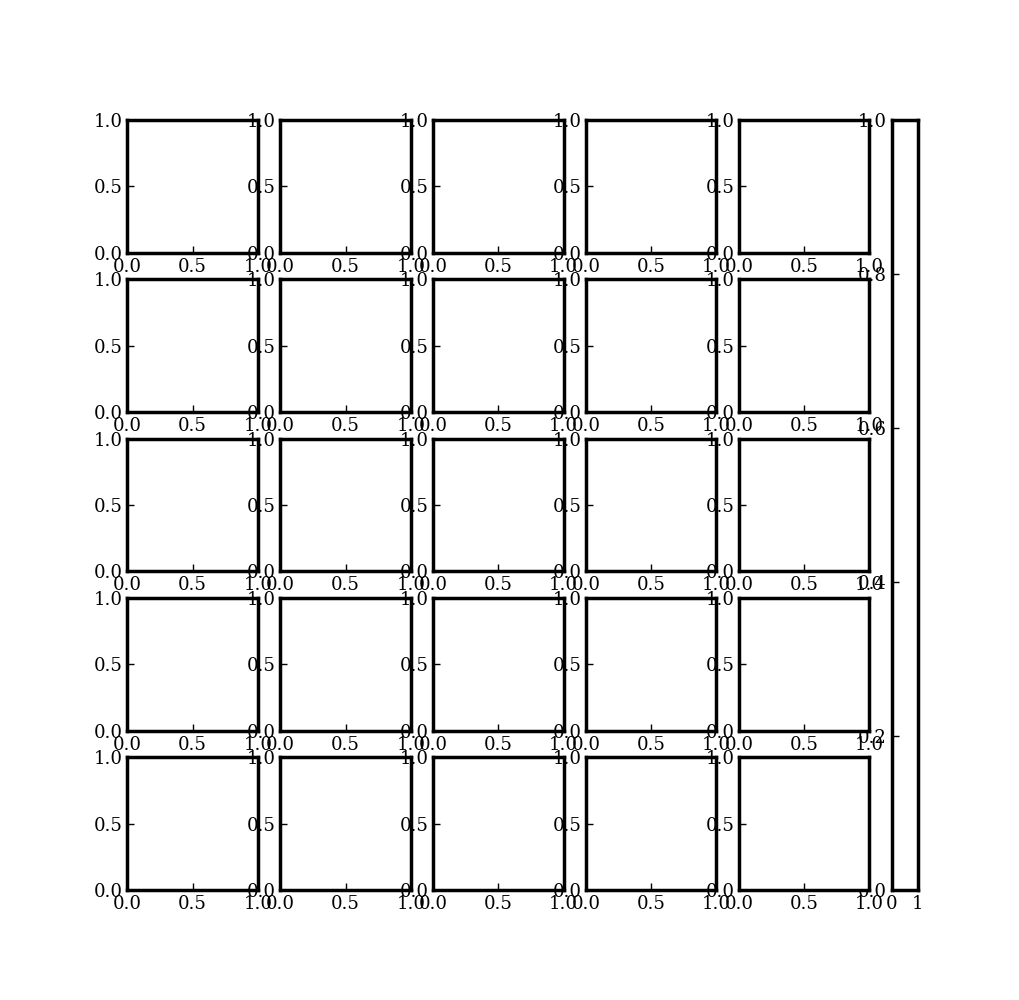

In [22]:
# ── Figure layout ─────────────────────────────────────────────────────────────
# 5×5 panels (letters a–y) + 1 narrow column (z) for the colorbar

fig_chan = plt.figure(figsize=(10.2, 10))
axes_chan = fig_chan.subplot_mosaic(
    """
    abcdez
    fghijz
    klmnoz
    pqrstz
    uvwxyz
    """,
    width_ratios=(1, 1, 1, 1, 1, 0.2),
)

In [33]:
# ── Channel edges ─────────────────────────────────────────────────────────────

chan_edges = np.linspace(VMIN_CHAN, VMAX_CHAN, N_PANELS + 1)  # shape (26,)

# ── Draw one panel per channel ────────────────────────────────────────────────

for i in range(N_PANELS):
    vmin, vmax = chan_edges[i], chan_edges[i + 1]

    # Number of HI spectral pixels falling inside this velocity slice
    # (used to normalise the moment-0 map to a per-channel average)
    

    # Compute the moment-0 map for this slice
    _, _, _, lon, lat, mom0 = map_loader.moment0_crop(
        CoordSource, TRACER, FOV,
        v_start=vmin, v_stop=vmax,
        shape=SHAPE
    )

    # Mask empty pixels so they are transparent
    mom0[mom0 == 0] = np.nan

    # ── Panel ────────────────────────────────────────────────────────────────
    ax = axes_chan[alphabet[i]]
    ax.clear()

    mappable = ax.imshow(
        mom0,
        vmin=VMIN_NORM, vmax=VMAX_NORM,
        extent=(lon[0], lon[-1], lat[0], lat[-1]),
        origin="lower",
        cmap=COLORMAP,
    )

    # Target marker
    ax.plot(center_l, center_b, ".", c="k")

    # Velocity range label
    ax.text(
        0.5, 0.1, f"{vmin:.0f} $-$ {vmax:.0f} km/s",
        color="k", transform=ax.transAxes, ha="center", fontsize=10,
    )

    # Beam FWHM circle (dashed) 
    # Here we use the widest beam, approximated to a circle 
    # see later for more accurate beam representation
    if SHOW_BEAM:
        beam_radius = 3.59 / 2  # degrees
        ax.add_patch(Circle(
            xy=(center_l.value, center_b.value),
            radius=beam_radius,
            fill=False,
            linestyle="--",
            edgecolor="k",
            linewidth=1,
        ))

    # Off-beam pointing marker
    if SHOW_OFFBEAM:
        for k,Coordoff in enumerate(CoordsOff) :
            ax.plot(
                Coordoff.galactic.l.value,
                Coordoff.galactic.b.value,
                "x", c=colors[k],
            )

    # Show axis labels only on the bottom-left panel
    if alphabet[i] == "u":
        ax.set_xlabel("Galactic longitude")
        ax.set_ylabel("Galactic latitude")
    else:
        ax.set_xticks([])
        ax.set_yticks([])

# ── Colorbar and title ────────────────────────────────────────────────────────

cbar = fig_chan.colorbar(mappable, cax=axes_chan["z"])
cbar.set_label("$T_b$ [K]")

fig_chan.suptitle(f"Channel map of {TRACER}")
fig_chan.subplots_adjust(hspace=0, wspace=0)

In [30]:
OUTNAME = f"CHANNEL_MAP_{SOURCE_NAME.replace(' ','_')}_{TRACER}" + FIG_FMT
fig_chan.savefig(FIG_DIR + OUTNAME, bbox_inches='tight')
print(f"Saved: {OUTNAME} in {FIG_DIR}")

Saved: CHANNEL_MAP_Tau_A_HI.pdf in ../figures/


### 5b. Region overview in NenuFAR beams

#### First fig: Spectra integrated in average NenuFAR beams centred on every pointing  

In [17]:
# ── Configuration ─────────────────────────────────────────────────────────────

TRACER    = "HI"
COLORMAP  = HI_cmap
SHAPE     = "square"
EXTEN     = nenufar_core.angular_resolution(frequency=19.14*u.MHz) # average NenuFAR beam size
print("Angular resolution of NenuFAR at 19.14 MHz = ",EXTEN)
FOV_BEAMS = (EXTEN,EXTEN)

VMIN, VMAX = VMIN_HI, VMAX_HI               # velocity axis limits for HI (km/s)
HI_TMIN, HI_TMAX =  -5, np.nanmax(SLICEHI)   # temperature axis limits for HI (K)
# HI_PEAK_VMIN, HI_PEAK_VMAX = -40, 40        # velocity range for peak detection


center_l = source_l   # change to an offset if you want 
center_b = source_b   # to center the chanel map elsewhere

Angular resolution of NenuFAR at 19.14 MHz =  1.8740712608453662 deg


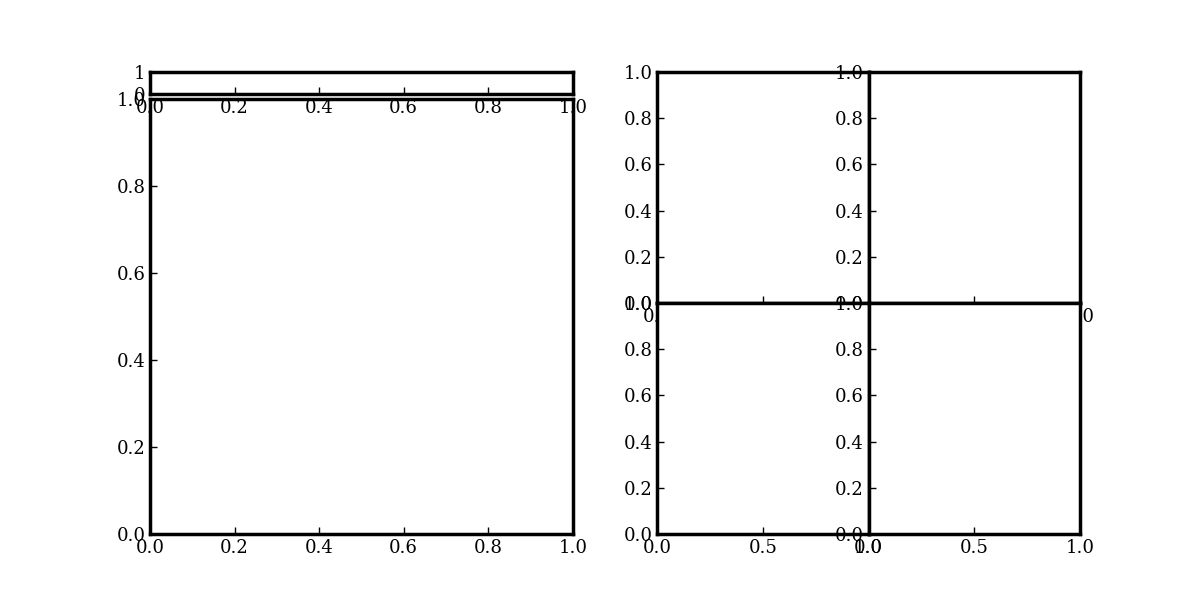

In [18]:

# fig_beams = plt.figure(figsize=(12,5))
fig_beams = plt.figure(figsize=(12, 6))

# Outer layout: panel A (left) | 2×2 group (right)
gs_outer = gridspec.GridSpec(1, 2, figure=fig_beams, wspace=0.2)

# Panel A
ax_A = fig_beams.add_subplot(gs_outer[0, 0])

# Inner 2×2 grid, tightly packed
gs_inner = gridspec.GridSpecFromSubplotSpec(
    2, 2, subplot_spec=gs_outer[0, 1], hspace=0, wspace=0
)
ax_a = fig_beams.add_subplot(gs_inner[0, 0])
ax_b = fig_beams.add_subplot(gs_inner[0, 1])
ax_c = fig_beams.add_subplot(gs_inner[1, 0])
ax_d = fig_beams.add_subplot(gs_inner[1, 1])

axs_beams = {"A": ax_A, "a": ax_a, "b": ax_b, "c": ax_c, "d": ax_d}
## colorbar
div0 = make_axes_locatable(axs_beams["A"])
mapcbarHI = div0.append_axes('top',size='5%',pad=0.05)


In [19]:
# ── Integrated spectra ─────────────────────────────────────────────────────────


# plot reference (Source)
_, velHI_ref, spectrumHI_ref, _, _, _ = map_loader.crop_circle(CoordSource, 'HI', FOV_BEAMS)


for k, (coord, col) in enumerate(zip(CoordsOff, colors)):
    axis = axs_beams[alphabet[k]]
    axis.clear()
    graphics.set_axes(axis)
    
    # Extract HI spectrum at this offset position.
    _, velHI_off, spectrumHI_off, _, _, _ = map_loader.crop_circle(coord, 'HI', FOV_BEAMS)

    axis.plot(velHI_ref, spectrumHI_ref, color="k", ls="--")
    axis.plot(velHI_off, spectrumHI_off, color=col)
    
    # Automatically detect and annotate spectral peaks in [-40, +40] km/s.
    cond_peak = (velHI_off < VMAX_HI) & (velHI_off > VMIN_HI)
    peak_idx_off = find_peaks(spectrumHI_off[cond_peak])[0]

    # Annotation of the peaks
    
    for ikm,km in enumerate(peak_idx_off):
        xm = velHI_off[cond_peak][km]
        ym = spectrumHI_off[cond_peak][km]
        top = (ikm%2)*ym
        axis.vlines(xm, -5, ym, lw=0.7, ls='--',color=col)
        axis.text( xm, top,f"{xm:.0f} km/s",
                      color=col,
                      fontsize=9,
                      ha = 'center',
                      va = 'bottom'
                 )

    axis.set_xlim(-49, 49)
    axis.set_ylim(HI_TMIN, HI_TMAX)

ax_a.set_xticks([])
ax_b.set_xticks([])
ax_b.set_yticks([])
ax_d.set_yticks([])



[]

In [53]:
# ── Moment 1 of the whole region ─────────────────────────────────────────────────────────
_, _, _, lon, lat, mom0, mom1 = map_loader.moment1_crop(
        CoordSource, TRACER, (2*SKY_EXTENSION_DEG*u.deg, 2*SKY_EXTENSION_DEG*u.deg),
        v_start=VMIN_HI, v_stop=VMAX_HI,
        shape=SHAPE
    )

axis = ax_A
axis.clear()
graphics.set_axes(axis)
m1 = ax_A.imshow(mom1, extent=(lon[0],lon[-1],lat[0],lat[-1]), origin = 'lower',cmap='jet')#, vmin=0,vmax=10)
graphics.overlay_positions(ax_A, CoordSource, CoordsOff, colors,
                  source_label=SOURCE_NAME, beam_width=EXTEN.value)

plt.colorbar(mappable=m1,cax = mapcbarHI, location='top')
mapcbarHI.set_title('Velocity (km/s)', size=15)

# Source extent ellipse (skipped if SOURCE_HAS_EXTENT is False).
if SOURCE_HAS_EXTENT:
    axbeam.add_patch(Ellipse(
        (source_l.value, source_b.value),
        width=_major_deg, height=_minor_deg,
        angle=SOURCE_ANGLE_DEG,
        facecolor=SOURCE_ELLIPSE_FACECOLOR,
        edgecolor=SOURCE_ELLIPSE_EDGECOLOR,
        linewidth=SOURCE_ELLIPSE_LINEWIDTH,
        zorder=6
    ))


In [27]:
# Final layout

# Bounding box of the 2×2 block from the axes positions
pos_tl = ax_a.get_position()  # top-left
pos_br = ax_d.get_position()  # bottom-right

x_center = (pos_tl.x0 + pos_br.x1) / 2
y_center = (pos_tl.y1 + pos_br.y0) / 2

fig_beams.text(
    x_center, pos_br.y0 - 0.05,
    "Velocity (km/s)",
    ha="center", va="top",
)
fig_beams.text(
    pos_tl.x0 - 0.05, y_center,
    "Brightness temperature (K)",
    ha="right", va="center", rotation=90,
)

# figboth.suptitle(f"HI spectra at offset positions — {SOURCE_NAME}", fontsize=13)
fig_beams.tight_layout()

In [28]:
OUTNAME = f"ALLBEAMS_{SOURCE_NAME.replace(' ','_')}_{TRACER}" + FIG_FMT
fig_beams.savefig(FIG_DIR + OUTNAME, bbox_inches='tight')
print(f"Saved: {OUTNAME} in {FIG_DIR}")

Saved: ALLBEAMS_Tau_A_HI.pdf in ../figures/


#### Second fig
Zoom-in on one pointing. Concentric real simulated NenuFAR beams and corresponding integrated spectra

In [36]:
# ── Configuration ─────────────────────────────────────────────────────────

CoordCenter = CoordSource
POINTING_INDEX = 0 # 0 if source, 1,2,3,4 if pointings
POINTING_BEAM  = EVERYBEAM[POINTING_INDEX,i]
FOV_REGION = FOV
DISPLAY = "Moment 0"



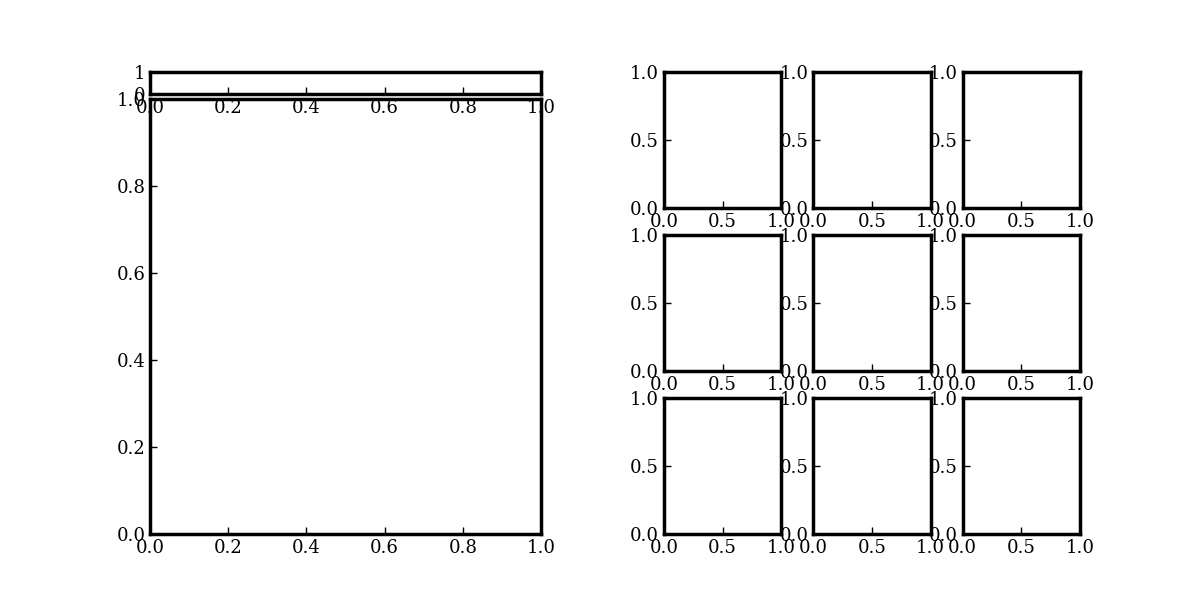

In [23]:
fig_beams2 = plt.figure(figsize=(12,6))
mosaic = fig_beams2.subplot_mosaic('''
                                A.abc
                                A.def
                                A.ghi
                                
                                
                                ''', width_ratios=(10,1.5,3,3,3))

## colorbar
div0 = make_axes_locatable(mosaic["A"])
mapcbarHI = div0.append_axes('top',size='5%',pad=0.05)

<xarray.DataArray 'stack-6b514baf09c2c09162300abe923b50ac' (lat_idx: 50,
                                                            lon_idx: 50)> Size: 20kB
dask.array<getitem, shape=(50, 50), dtype=float64, chunksize=(50, 50), chunktype=numpy.ndarray>
Dimensions without coordinates: lat_idx, lon_idx
Attributes:
    center_l:   [np.float64(184.55754381479818), np.float64(181.90999999), np...
    center_b:   [np.float64(-5.784273689946599), np.float64(-5.83000002), np....
    extension:  5.0
    n_grid:     50
    frame:      galactic

In [30]:
# ── Moment 0 centred on one pointing ─────────────────────────────────────────────────────

_, _, _, lon, lat, mom0,mom1 = map_loader.moment1_crop(CoordCenter, 'HI', FOV, v_start=VMIN_HI,v_stop=VMAX_HI, shape='square')
axis = mosaic["A"]
axis.clear()

graphics.set_axes(axis)

match DISPLAY :
    case "Moment 0" :
        IMAGE = mom0
        COLORMAP = HI_cmap
        CBAR_LABEL = "$T_b$ (K)"
    case "Moment 1" :
        IMAGE = mom1
        COLORMAP = "jet"
        CBAR_LABEL = "Velocity (km/s)"

img = axis.imshow(IMAGE, extent=(lon[0],lon[-1],lat[0],lat[-1]), origin = 'lower',cmap=COLORMAP)
plt.colorbar(mappable=img,cax = mapcbarHI, location='top')
mapcbarHI.set_title(CBAR_LABEL)

# Source extent ellipse (skipped if SOURCE_HAS_EXTENT is False).
if SOURCE_HAS_EXTENT:
    axis.add_patch(Ellipse(
        (source_l.value, source_b.value),
        width=_major_deg, height=_minor_deg,
        angle=SOURCE_ANGLE_DEG,
        facecolor=SOURCE_ELLIPSE_FACECOLOR,
        edgecolor=SOURCE_ELLIPSE_EDGECOLOR,
        linewidth=SOURCE_ELLIPSE_LINEWIDTH,
        zorder=6
    ))


# ── Consecutive beams on map ───────────────────────────────────────────────────────────────
# ── Exact spectra inside the beams ─────────────────────────────────────────────────────────

beam_colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(BEAM_FREQUENCIES_MHZ)))

for fbeam, fwhm_deg, bcol in zip(BEAM_FREQUENCIES_MHZ, BEAM_ANGULAR_RES, beam_colors):
    radius = fwhm_deg / 2
    table = POINTING_BEAM[i]
    
    

# # Angular parameter for drawing circles (parametric angle array).
# theta = np.linspace(0, 2 * np.pi, 200)

# # Grid used for the NenuFAR beam simulation.
# center_l = source_l.value
# center_b = source_b.value
# extension = SKY_EXTENSION_DEG * u.deg
# lon_grid, lat_grid = np.meshgrid(
#     np.linspace(center_l - extension.value, center_l + extension.value, 50),
#     np.linspace(center_b - extension.value, center_b + extension.value, 50)
# )

# # Figure: CO moment map with NenuFAR beam contours at each frequency.
# figbeam, axbeam = plt.subplots(1, 1, figsize=(8, 7))

# # Background: CO moment-0 map.
# imb = axbeam.imshow(
#     mom0_HI_vel,
#     extent=(lonslice_HI[0], lonslice_HI[-1], latslice_HI[0], latslice_HI[-1]),
#     origin='lower', cmap='Greys'
# )
# plt.colorbar(imb, ax=axbeam, label=r'$T_b$ (K)')

# # Mark the source position.
# axbeam.plot(source_l.value, source_b.value, '*', c='black', ms=15,
#             label=SOURCE_NAME, zorder=5)
# # Source extent ellipse (skipped if SOURCE_HAS_EXTENT is False).
# if SOURCE_HAS_EXTENT:
#     axbeam.add_patch(Ellipse(
#         (source_l.value, source_b.value),
#         width=_major_deg, height=_minor_deg,
#         angle=SOURCE_ANGLE_DEG,
#         facecolor=SOURCE_ELLIPSE_FACECOLOR,
#         edgecolor=SOURCE_ELLIPSE_EDGECOLOR,
#         linewidth=SOURCE_ELLIPSE_LINEWIDTH,
#         zorder=6
#     ))

# # Draw HPBW circles for each requested frequency.
# beam_colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(BEAM_FREQUENCIES_MHZ)))
# for fbeam, bcol in zip(BEAM_FREQUENCIES_MHZ, beam_colors):
#     # Angular resolution at this frequency [deg].
#     fwhm_deg = nenufar_core.angular_resolution(frequency=fbeam * u.MHz).value
#     radius = fwhm_deg / 2
#     circle_l = radius * np.cos(theta) + source_l.value
#     circle_b = radius * np.sin(theta) + source_b.value
#     axbeam.plot(circle_l, circle_b, '--', c=bcol, linewidth=2,
#                 label=f"{fbeam} MHz  (HPBW={fwhm_deg:.2f}°)")

# axbeam.set_xlabel("Galactic Longitude", size=13)
# axbeam.set_ylabel("Galactic Latitude", size=13)
# axbeam.set_title(f"NenuFAR beams overlaid on CO map — {SOURCE_NAME}", size=13)
# axbeam.legend(fontsize=9, loc='upper right')
# graphics.set_axes(axbeam)
# figbeam.tight_layout()


NameError: name 'beam_' is not defined

### 7c. HI Interactive Exploration plot

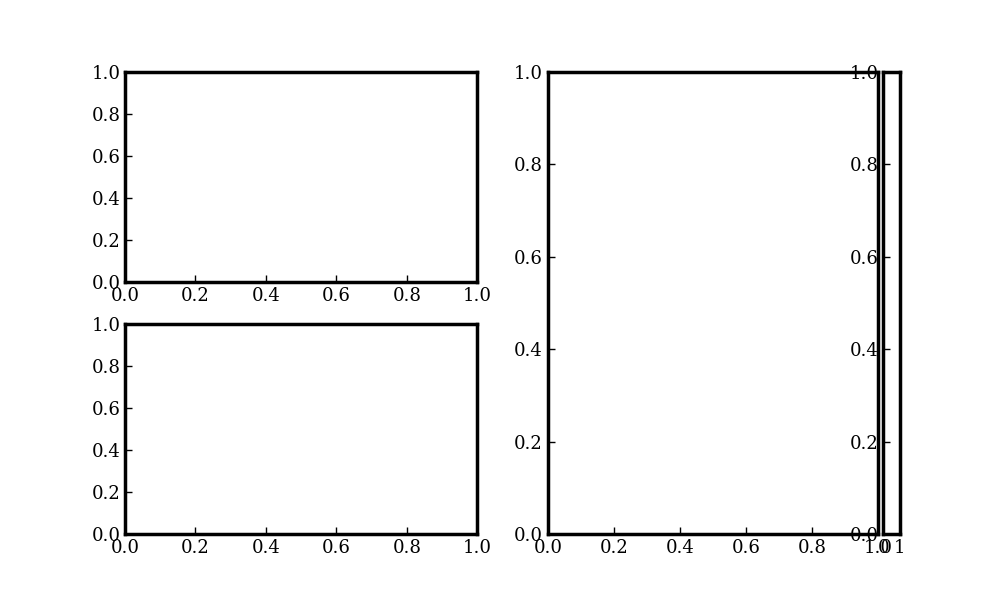

In [50]:
# Layout: mosaic with HI spectrum (A), dust profile (C) and moment map (B).
figHI, mosaic = plt.subplot_mosaic(
    '''
    AB
    CB
    ''',
    figsize=(10, 6)
)

## colorbar
div0 = make_axes_locatable(mosaic["B"])
mapcbarHI = div0.append_axes('right',size='5%',pad=0.05)


In [51]:

# --- Panel A: HI mean spectrum ---
axHI = mosaic['A']
axHI.clear()

axHI.plot(velHI, spectrumHI / np.nanmax(spectrumHI), c='gray',
          label="Full spectrum")
axHI.plot(velHI[condHI], spectrumHI[condHI] / np.nanmax(spectrumHI),
          c='red', label=f"{VMIN_HI}–{VMAX_HI} km/s")
axHI.axvline(VMIN_HI, 0.05, 0.95, color='red', linestyle='dotted')
axHI.axvline(VMAX_HI, 0.05, 0.95, color='red', linestyle='dotted')
axHI.set_xlim(-20, 30)
axHI.set_ylim(-0.1, 1.1)
axHI.set_xlabel("Velocity (km/s)")
axHI.set_ylabel("Relative intensity")
axHI.set_title(f"HI spectrum averaged\nover the NenuFAR beam ({SOURCE_NAME})")
axHI.legend(fontsize=8)
graphics.set_axes(axHI)

# --- Panel C: Dust extinction profile ---
axdust = mosaic['C']
axdust.clear()

axdust.plot(radiitot, EXTINC_source_los / np.nanmax(EXTINC_source_los),
            c='gray', label=f"{SOURCE_NAME} LOS")
axdust.set_xlabel("Distance from the Sun (kpc)")
axdust.set_ylabel("Relative absorption")
axdust.set_title("Spatial distribution of dust")
axdust.set_ylim(-0.1, 1.1)
graphics.set_axes(axdust)

# --- Panel B: HI moment-0 map ---
axmapHI = mosaic['B']
axmapHI.clear()
mapcbarHI.clear()
im = axmapHI.imshow(
    mom0_HI,
    extent=(lonslice_HI[0], lonslice_HI[-1], latHI_full[0], latHI_full[-1]),
    origin='lower', cmap='Reds'
)
plt.colorbar(im, cax=mapcbarHI, label=r'$T_b$ (K)')

# Source position and offset markers.
graphics.overlay_positions(axmapHI, CoordSource, CoordsOff, colors,
                  source_label=SOURCE_NAME)

# Source extent ellipse (skipped if SOURCE_HAS_EXTENT is False).
if SOURCE_HAS_EXTENT:
    axmapHI.add_patch(Ellipse(
        (source_l.value, source_b.value),
        width=_major_deg, height=_minor_deg,
        angle=SOURCE_ANGLE_DEG,
        facecolor=SOURCE_ELLIPSE_FACECOLOR,
        edgecolor=SOURCE_ELLIPSE_EDGECOLOR,
        linewidth=SOURCE_ELLIPSE_LINEWIDTH,
        zorder=6
    ))
axmapHI.set_xlabel("Galactic Longitude", size=12)
axmapHI.set_ylabel("Galactic Latitude", size=12)
axmapHI.set_title(f"HI moment 0 ({VMIN_HI}–{VMAX_HI} km/s)")
axmapHI.legend(fontsize=7)
graphics.set_axes(axmapHI, label_pad=10)

figHI.suptitle(f"HI analysis — {SOURCE_NAME}", fontsize=14)
figHI.tight_layout()

In [ ]:
figHI.savefig(OUT_HI_PDF)
print(f"Saved: {OUT_HI_PDF}")

## Cube CO : extraction, moments et comparaison aux faisceaux


## CO Cube


In [43]:
# Chargement / préparation des données CO.
loader = maps.MapLoader("Tau",
                        path_co='../maps/COmaps/',
                        path_hi='../maps/HImaps/')
# ...
SLICECO, velCO, spectrumCO, lonslice_CO, latslice_CO, mom0_fullsp_CO = loader.crop_square(Coord, "CO", fov)

In [46]:
tracer = 'CO'
fov = (10*u.deg,10*u.deg)
Coord = Coordoff3
SLICECO,velCO, spectrumCO, lonslice_CO, latslice_CO, mom0_fullsp_CO = loader.crop_square(Coord,tracer, fov)

pixdim = SLICECO.shape


In [47]:
SLICECOnonan = np.copy(SLICECO)
SLICECOnonan[np.isnan(SLICECO)] = 1e-16
SLICECOnonan[SLICECOnonan<1.1] = 1e-16
mom1 = np.sum(SLICECOnonan*velCO, axis=2)/np.sum(SLICECOnonan,axis=2)#, weights=SLICECOnonan)
# mom1 = np.average(SLICECOnonan*velCO, axis=2, weights=SLICECOnonan)
mom1[mom1==4.227500127788173] = np.nan
mom1CO = np.copy(mom1)


In [48]:
# Diagnostic rapide — conserver uniquement si cette vérification est utile.
(SLICECOnonan*velCO).shape, SLICECOnonan.shape, velCO.shape


((64, 80, 81), (64, 80, 81), (81,))

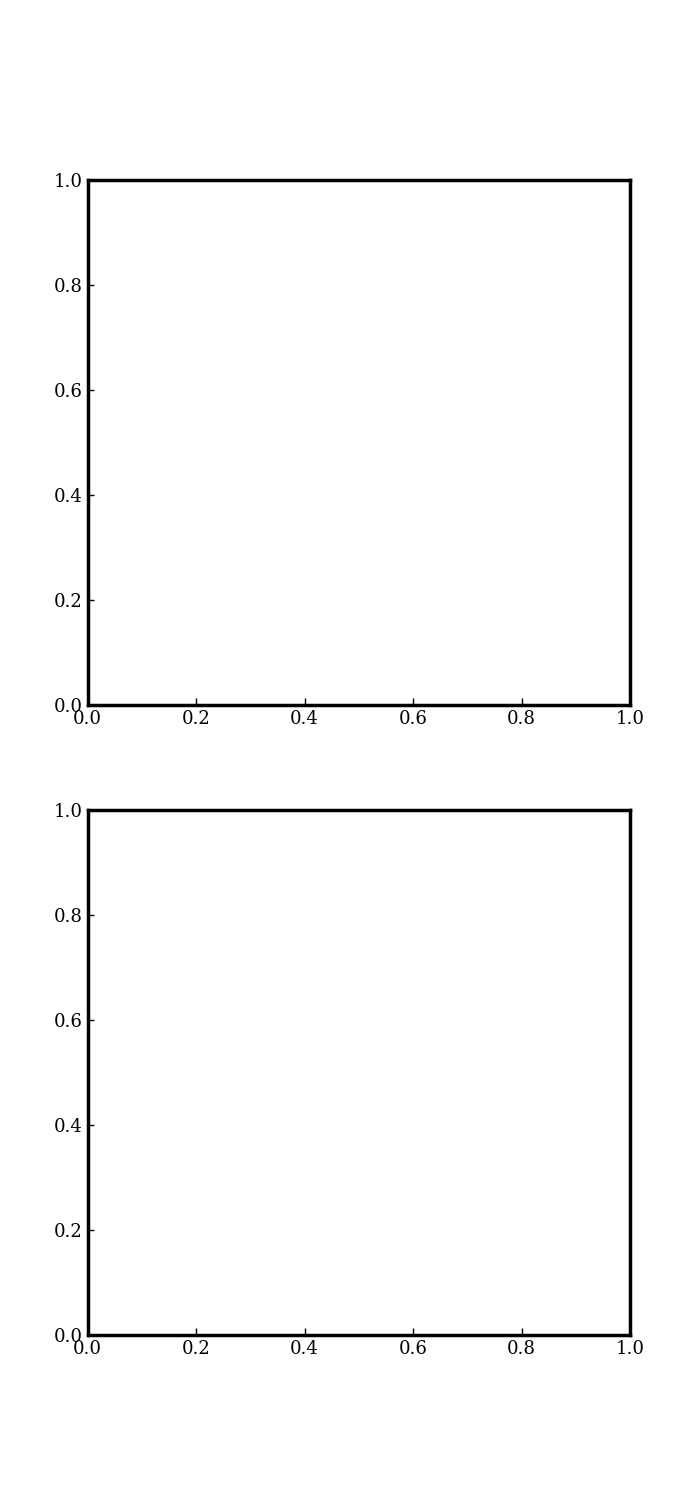

In [49]:
### exemple of CO in different nenufar beams

figCO = plt.figure(figsize=(7,15))
# mosaicCO = figCO.subplot_mosaic('''
#                                 bb.cde
#                                 BB.cde
#                                 BB.fgh
#                                 BB.ijk
#                                 BB.ijk
#                                 ''', width_ratios=(3,3,.5,2,2,2), height_ratios=(1,10,11,10,1))
mosaicCO = figCO.subplot_mosaic('''
                                A
                                B
                                ''')#,height_ratios = (0.5,10,3,0.5,10))

# axmap0 = figCO.add_axes([0.15, 0.1, 0.7, 0.3])
# map0cbar = figCO.add_axes([0.15, 0.4, 0.7, 0.02])
#
# axmap1 = figCO.add_axes([0.15, 0.1+.5, 0.7, 0.3])
# map1cbar = figCO.add_axes([0.15, 0.4+.5, 0.7, 0.02])

# axmap0 = mosaic["A"]
# # axmap1 = mosaicHI["C"]
# # map0cbar = mosaic["a"]
# div0 = make_axes_locatable(axmap0)
# map0cbar = div0.append_axes('top',size='5%',pad=0.05)

# axmap1 = mosaic["B"]
# # axmap1 = mosaicHI["C"]
# # map1cbar = mosaic["b"]
# div1 = make_axes_locatable(axmap1)
# map1cbar = div1.append_axes('top',size='5%',pad=0.05)


In [51]:
# dust fov
da_dust_fov = da.sum(dim='x')[:,:,0]


In [53]:
#velos = [-24,-10,4,8,13]
# taua_spatial_rep = matplotlib.patches.Ellipse((taua_l.value,taua_b.value), 7/60, 5/60,angle= alpha, facecolor='w',edgecolor='k')


velos = []
extens =2.1
tracer = 'CO'
mom0_fullsp = eval(f"mom0_fullsp_{tracer}")
lonslice = eval(f"lonslice_{tracer}")
latslice = eval(f"latslice_{tracer}")
mosaic = eval(f"mosaic{tracer}")
vel = eval(f"vel{tracer}")
figtracer = eval(f"fig{tracer}")

Frequencies = np.linspace(1/85,0.1,9)
dNenu = nenufar_core.angular_resolution(frequency=1/Frequencies*u.MHz).value
axmap0 = mosaic["A"]
# axmap1 = mosaicHI["C"]
# map0cbar = mosaic["a"]
div0 = make_axes_locatable(axmap0)
map0cbar = div0.append_axes('top',size='5%',pad=0.05)
axmap0.clear()
map0cbar.clear()

axmap1 = mosaic["B"]
# axmap1 = mosaicHI["C"]
# map1cbar = mosaic["b"]
div1 = make_axes_locatable(axmap1)
map1cbar = div1.append_axes('top',size='5%',pad=0.05)

axmap1.clear()
map1cbar.clear()
# ============== POINTINGS ==========================
exten = nenufar_core.angular_resolution(frequency=19.14*u.MHz).value
### taua
color = 'k'
l,b = taua_l.value, taua_b.value
circle = exten/2 * np.cos(theta)+taua_l.value,exten/2 * np.sin(theta) + taua_b.value
# axmap0.plot(*circle,'--', c=color, linewidth=3)

taua_spatial_rep = matplotlib.patches.Ellipse((taua_l.value,taua_b.value), 7/60, 5/60,angle= alpha, facecolor='w',edgecolor='k')
# axmap0.plot(l,b,"*",c=color,ms=15)
axmap0.add_patch(taua_spatial_rep)
taua_spatial_rep = matplotlib.patches.Ellipse((taua_l.value,taua_b.value), 7/60, 5/60,angle= alpha, facecolor='w',edgecolor='k')
# axmap0.plot(l,b,"*",c=color,ms=15)
axmap1.add_patch(taua_spatial_rep)
# ### CO clouds - on
# color = 'blue'
# Coord = Coordoff1
# center_b = Coord.galactic.b
# center_l = Coord.galactic.l

# l,b = center_l.value, center_b.value
# circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
# axmap0.plot(*circle,'--', c=color, linewidth=3)
# axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

# ### CO clouds - off
# color = 'green'
# Coord = Coordoff2
# center_b = Coord.galactic.b
# center_l = Coord.galactic.l

# l,b = center_l.value, center_b.value
# circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
# axmap0.plot(*circle,'--', c=color, linewidth=3)
# axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

# ### HI clouds - on
# color = 'orange'
# Coord = Coordoff3
# center_b = Coord.galactic.b
# center_l = Coord.galactic.l

# l,b = center_l.value, center_b.value
# circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
# axmap0.plot(*circle,'--', c=color, linewidth=3)
# axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

# ### HI clouds - off
# color = 'red'
# Coord = Coordoff4
# center_b = Coord.galactic.b
# center_l = Coord.galactic.l

# l,b = center_l.value, center_b.value
# circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
# axmap0.plot(*circle,'--', c=color, linewidth=3)
# axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

# ===================================================


m0 = axmap0.imshow(mom0_fullsp, extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin = 'lower',cmap='Blues')
# m0 = axmap0.imshow(mom1, extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin = 'lower',cmap='Blues', vmin=0,vmax=10)
graphics.set_axes(axmap0, pad=10)
# m1 = axmap1.imshow(mom1_fullsp/1000, extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin = 'lower', cmap='rainbow')
plt.colorbar(mappable=m0,cax = map0cbar, location='top')
map0cbar.set_title('$T_b$ (K)', size=15)

# m0 = axmap0.imshow(mom0_fullsp, extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin = 'lower',cmap='Blues')
m1 = axmap1.imshow(mom1, extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin = 'lower',cmap='rainbow', vmin=0,vmax=10)
graphics.set_axes(axmap1, pad=10)
# m1 = axmap1.imshow(mom1_fullsp/1000, extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin = 'lower', cmap='rainbow')
plt.colorbar(mappable=m1,cax = map1cbar, location='top')
map1cbar.set_title('Velocity (km/s)', size=15)

# axmap0.plot(center_l.value,center_b.value,".",c='black',ms=10)

velos = []
# target_tracking = Pointing.target_tracking(
#     target=targ,
#     time=obs_times,
#     duration=dt
# )

imgdust = axmap0.contour(dustfov,extent=(off_3[0]-5,off_3[0]+5,off_3[1]-5,off_3[1]+5),cmap='Greys',origin="lower",levels=15)
axmap1.contour(dustfov,extent=(off_3[0]-5,off_3[0]+5,off_3[1]-5,off_3[1]+5),cmap='Greys',origin="lower",levels=15)
axmap0.set_xlabel("Galactic Longitude", size=15)
axmap0.set_ylabel("Galactic Latitude", size=15)

axmap1.set_xlabel("Galactic Longitude", size=15)
axmap1.set_ylabel("Galactic Latitude", size=15)
# figtracer.supxlabel("Velocity (km/s)", size=16, x=0.72, y=0.01)
# figtracer.supylabel('$T_b$ (K)', size=16, x=0.91, y=0.5,rotation=270)
# figHI.tight_layout()
Coord = Coordoff3
center_b = Coord.galactic.b
center_l = Coord.galactic.l
axmap0.set_xlim(center_l.value+extens,center_l.value-extens)
axmap0.set_ylim(center_b.value-extens,center_b.value+extens)

axmap1.set_xlim(center_l.value+extens,center_l.value-extens)
axmap1.set_ylim(center_b.value-extens,center_b.value+extens)
# figHI.tight_layout()
# figCO.subplots_adjust(wspace=0, hspace=0)

# figCO.suptitle('CO moment 1 map of the region around Tau A')
figCO.tight_layout()
# figCO.savefig('CO-moments.pdf')


TypeError: set_axes() got an unexpected keyword argument 'pad'

In [52]:
plt.colorbar(imgdust, label="$A_{dust}$")


NameError: name 'imgdust' is not defined

In [ ]:
# Export de la figure générée dans les cellules précédentes.
figCO.savefig('CO-moments.pdf')


In [ ]:
## DEUXIEME FIG : consecutive beams
### exemple of CO in different nenufar beams

figCO2 = plt.figure(figsize=(6,12))
mosaicCO = figCO2.subplot_mosaic('''
                                BBB
                                ...
                                cde
                                fgh
                                ijk
                                ''', height_ratios=(10,1.5,3,3,3))
# mosaicCO = figCO.subplot_mosaic('''

#                                 BB
#                                 ''')


In [ ]:
#velos = [-24,-10,4,8,13]
# taua_spatial_rep = matplotlib.patches.Ellipse((taua_l.value,taua_b.value), 7/60, 5/60,angle= alpha, facecolor='w',edgecolor='k')
tracer = 'CO'
fov = (5*u.deg,5*u.deg)
Coord = CoordTaua
SLICECO,velCO, spectrumCO, lonslice_CO, latslice_CO, mom0_fullsp_CO = maps.crop_map_square(Coord,tracer, fov)

pixdim = SLICECO.shape
velos = []
extens =5
tracer = 'CO'
mom0_fullsp = eval(f"mom0_fullsp_{tracer}")
lonslice = eval(f"lonslice_{tracer}")
latslice = eval(f"latslice_{tracer}")
mosaic = eval(f"mosaic{tracer}")
vel = eval(f"vel{tracer}")
figtracer = eval(f"fig{tracer}")

Frequencies = np.linspace(1/85,0.1,9)
dNenu = nenufar_core.angular_resolution(frequency=1/Frequencies*u.MHz).value
axmap0 = mosaic["B"]
# axmap1 = mosaicHI["C"]
# map0cbar = mosaic["a"]
div0 = make_axes_locatable(axmap0)
map0cbar = div0.append_axes('top',size='5%',pad=0.05)
axmap0.clear()
map0cbar.clear()
# ============== POINTINGS ==========================
exten_max = nenufar_core.angular_resolution(frequency=19.14*u.MHz).value
### taua
color = 'k'
l,b = taua_l.value, taua_b.value

taua_spatial_rep = matplotlib.patches.Ellipse((taua_l.value,taua_b.value), 7/60, 5/60,angle= alpha, facecolor='w',edgecolor='k')
axmap0.add_patch(taua_spatial_rep)
tracer = "CO"

# ### CO clouds - on
# color = 'blue'
# Coord = Coordoff1
# center_b = Coord.galactic.b
# center_l = Coord.galactic.l

# l,b = center_l.value, center_b.value
# circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
# axmap0.plot(*circle,'--', c=color, linewidth=3)
# axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

# ### CO clouds - off
# color = 'green'
# Coord = Coordoff2
# center_b = Coord.galactic.b
# center_l = Coord.galactic.l

# l,b = center_l.value, center_b.value
# circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
# axmap0.plot(*circle,'--', c=color, linewidth=3)
# axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

# ### HI clouds - on
# color = 'orange'
# Coord = Coordoff3
# center_b = Coord.galactic.b
# center_l = Coord.galactic.l

# l,b = center_l.value, center_b.value
# circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
# axmap0.plot(*circle,'--', c=color, linewidth=3)
# axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

# ### HI clouds - off
# color = 'red'
# Coord = Coordoff4
# center_b = Coord.galactic.b
# center_l = Coord.galactic.l

# l,b = center_l.value, center_b.value
# circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
# axmap0.plot(*circle,'--', c=color, linewidth=3)
# axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

# ===================================================


m0 = axmap0.imshow(mom0_fullsp, extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin = 'lower',cmap='Blues')
# m0 = axmap0.imshow(mom1, extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin = 'lower',cmap='Blues', vmin=0,vmax=10)
graphics.set_axes(axmap0, pad=10)
# m1 = axmap1.imshow(mom1_fullsp/1000, extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin = 'lower', cmap='rainbow')
plt.colorbar(mappable=m0,cax = map0cbar, location='top')
map0cbar.set_title('$T_b$ (K)', size=15)


for i in range(len(Frequencies)):
#     i = len(Frequencies)
    exten = dNenu[i]
    axspectrum = mosaic[alphabet[i+2]]
    axspectrum.clear()

#     for v in velos:

#         axspectrum.vlines(v,0, spect[np.nanargmin(np.abs(velHI-v))],color='k', linewidth =1)


#     circle = exten/2 * np.cos(theta)+l,exten/2 * np.sin(theta) + b
#     axmap0.plot(*circle,'--', color=colors[i])

        # we compare to the nenufar actual beam
    table = np.array(beam_[i].reshape((50, 50)) )
    # regridding
    X,Y = np.meshgrid(lonslice,latslice)
    #
    regrided_beam= RegularGridInterpolator(points=(lon[0],lat[:,0]),values=table, method="linear")((X,Y))

    SLICECO_test = np.copy(SLICECO)
    SLICECO_test[regrided_beam<np.max(regrided_beam)/2, :] = np.nan

    moment0 = np.nanmean(SLICECO_test, axis=2)
    moment0[moment0==0] = np.nan
    spectrum = np.nanmean(SLICECO_test, axis=(0,1))


    axspectrum.plot(vel,spectrum, c = colors[i])
    if exten>exten_max :
        axmap0.contour(table.T,levels=[np.max(table)/2], extent=(lon[0,0],lon[0,-1],lat[0,0],lat[-1,0]), colors = colors[i],linestyles=['dotted'])
    else :
        axmap0.contour(table.T,levels=[np.max(table)/2], extent=(lon[0,0],lon[0,-1],lat[0,0],lat[-1,0]), colors = colors[i])

#     axmap0.imshow(moment0,extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin="lower")

    # axmap0.text(l,-exten/2+b,f"{dNenu[i]:.2f}°",size=13,ha="center",va="top" ,color=colors[i]) #,transform=axmap0.transAxes)

    axspectrum.set_title(f'{1/Frequencies[i]:.1f} MHz\n{dNenu[i]:.2f}°', size=15, y=0.5, x=0.09,ha='left')
    graphics.set_axes(axspectrum,pad=7)
    axspectrum.set_xlim(-19,19)
    axspectrum.set_ylim(-0.01,0.9)
    axspectrum.set_yticklabels([])
    if i<6:
        axspectrum.set_xticklabels([])


axmap0.set_xlabel("Galactic Longitude", size=15)
axmap0.set_ylabel("Galactic Latitude", size=15)
extens = 2.4
Coord = CoordTaua
center_b = Coord.galactic.b
center_l = Coord.galactic.l
axmap0.set_xlim(center_l.value+extens,center_l.value-extens)
axmap0.set_ylim(center_b.value-extens,center_b.value+extens)

figCO2.supxlabel("Velocity (km/s)", size=16, x=0.5, y=0.05)
mosaicCO["f"].set_ylabel('$T_b$ (K)')#, size=16, x=0.91, y=0.5)#,rotation=270)
# figCO.subplots_adjust(wspace=0, hspace=0)

# figCO.suptitle('CO moment 1 map of the region around Tau A')
figCO2.tight_layout()
figCO2.subplots_adjust(wspace=0, hspace=0)

figCO2.savefig('CO-beams.pdf')


In [ ]:
extens = 2.4
Coord = CoordTaua
center_b = Coord.galactic.b
center_l = Coord.galactic.l
axmap0.set_xlim(center_l.value+extens,center_l.value-extens)
axmap0.set_ylim(center_b.value-extens,center_b.value+extens)
figCO2.supxlabel("Velocity (km/s)", size=14, x=0.5, y=0.03)
# figCO.subplots_adjust(wspace=0, hspace=0)

# figCO.suptitle('CO moment 1 map of the region around Tau A')
figCO2.tight_layout()
figCO2.subplots_adjust(wspace=0, hspace=0)
figCO2.savefig('CO-beams.pdf')


In [ ]:
# Diagnostic rapide — conserver uniquement si cette vérification est utile.
np.max(latslice), np.max(lat)


## Cube HI : extraction, moments et comparaison aux faisceaux


## HI


In [ ]:
# Chargement / préparation des données HI.
tracer = 'HI'
fov = (10*u.deg,10*u.deg)
# Coord = Coordoff3
Coord = CoordTaua
SLICEHI,velHI, spectrumHI, lonslice_HI, latslice_HI, mom0_fullsp_HI = maps.crop_map_square(Coord,tracer, fov)
pixdim = SLICEHI.shape


In [ ]:
# maxi = np.nanmax(SLICEHInonan)
SLICEHInonan = np.copy(SLICEHI).T
SLICEHInonan[np.isnan(SLICEHI).T] = 0
maxi = np.nanmax(SLICEHInonan)
SLICEHInonan[SLICEHInonan<0.1*maxi] = 0
mom1 = np.nanmean(SLICEHInonan*velHI, axis=2) /np.nanmean(SLICEHInonan,axis=2)#, weights=SLICECOnonan)
# mom1 = np.average(SLICEHInonan*velHI, axis=2, weights=SLICEHInonan)
# mom1[mom1==4.227500127788173] = np.nan
mom1HI = np.copy(mom1)


In [ ]:
tracer = 'HI'
fov = (3*u.deg,3*u.deg)
Coord = Coordoff3
vmin_HI = -50
vmax_HI = -30
SLICEHI,velHI, spectrumHI, lonslice_HI, latslice_HI, mom0_fullsp_HI = maps.cropped_mom0(Coord,tracer, fov,vmin_HI,vmax_HI, shape="square")


In [ ]:
axmap0.clear()
axmap0.plot(velHI,spectrumHI)


In [ ]:
# Diagnostic rapide — conserver uniquement si cette vérification est utile.
SLICEHInonan.max()


In [ ]:
# Diagnostic rapide — conserver uniquement si cette vérification est utile.
mom1


In [ ]:
# Diagnostic rapide — conserver uniquement si cette vérification est utile.
velHI[1]-velHI[0]


In [ ]:
### exemple of CO in different nenufar beams

figHI = plt.figure(figsize=(10,5))
# mosaicCO = figCO.subplot_mosaic('''
#                                 bb.cde
#                                 BB.cde
#                                 BB.fgh
#                                 BB.ijk
#                                 BB.ijk
#                                 ''', width_ratios=(3,3,.5,2,2,2), height_ratios=(1,10,11,10,1))
# mosaicHI = figHI.subplot_mosaic('''
#                                 A
#                                 B
#                                 ''')#, height_ratios = (0.5,10))

mosaicHI = figHI.subplot_mosaic('''
                                AB
                                AC
                                ''')#,height_ratios=(3,5))

axmap1 = mosaicHI["A"]
axmap0 = mosaicHI["B"]
axmap2 = mosaicHI["C"]

# axes = figHI.subplots(3,2)


In [ ]:
radiusmin = 0.1
radiusmax = 0.3
# radiusmax = 1.7
vmin_HI = 0
vmax_HI = 10
pct = 0.50

radius = np.arange(radiusmin,radiusmax,0.005)
exten = nenufar_core.angular_resolution(frequency=19.14*u.MHz).value
fov05 = nenufar_core.angular_resolution(frequency=19.14*u.MHz).value/2
fov = (fov05*u.deg,fov05*u.deg)

dustlos= maps.DustMap().extinction_los(Coord, fov, delta)
dustfov = maps.get_EXTIN_fov(Coord, fov, delta)
Coord = Coordoff1
dustlos_cut = maps.DustMap().extinction_los(Coord,fov,delta,radiusmin=radiusmin,radiusmax=radiusmax)
dustfov_cut = maps.get_EXTIN_fov(Coord,fov,delta,radiusmin=radiusmin,radiusmax=radiusmax)
axmap0.clear()
axmap1.clear()
axmap2.clear()
axmap0.plot(radiitot,dustlos,'k')
axmap0.plot(radius,dustlos_cut,'r')
# imgdust = axmap1.contour(dustfov,extent=(off_3[0]-5,off_3[0]+5,off_3[1]-5,off_3[1]+5),cmap='Greys',origin="lower",levels=15)
# m1 = axmap1.imshow(mom1, extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin = 'lower',cmap='jet',vmax=7)
# axmap1.contour(dustfov_cut,extent=(off_3[0]-fov05,off_3[0]+fov05,off_3[1]-fov05,off_3[1]+fov05),cmap='Greys',origin="lower",levels=15)

tracer = 'HI'
fovHI = (5*u.deg,5*u.deg)
Coord = Coordoff1

SLICEHI,velHI, spectrumHI, lonslice_HI, latslice_HI, mom0_fullsp_HI = maps.cropped_mom0(Coord,tracer, fovHI,vmin_HI,vmax_HI, shape="square")

indmin = np.where(velHI>vmin_HI)[0][1]
indmax = np.where(velHI<vmax_HI)[0][-1]
SLICE_true = SLICEHI[indmin:indmax,:,:]

m0 = axmap1.imshow(np.nanmean(SLICE_true,axis=0), extent=(lonslice_HI[0],lonslice_HI[-1],latslice_HI[0],latslice_HI[-1]), origin = 'lower',cmap='Reds')

condv = (velHI<vmax_HI)*(velHI>vmin_HI)

axmap2.plot(velHI,spectrumHI,c='k')
axmap2.plot(velHI[condv],spectrumHI[condv],c='r')
# ### HI clouds - on
color = 'blue'
Coord = Coordoff1
center_b = Coord.galactic.b
center_l = Coord.galactic.l

l,b = center_l.value, center_b.value
circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
axmap1.plot(*circle,'--', c=color, linewidth=3)
axmap1.plot(center_l.value,center_b.value,".",c=color,ms=10)

extens = 2

axmap1.set_xlim(center_l.value+extens,center_l.value-extens)
axmap1.set_ylim(center_b.value-extens,center_b.value+extens)

extinlosCO = np.copy(dustlos_cut)
EXTINTAUA_los = np.copy(dustlos)
EXTINTAUATOT = np.copy(dustfov)
EXTIN_k_CO = np.copy(dustfov_cut)

maxi = np.nanmax(extinlosCO)
maxi_rel = maxi/np.nanmax(EXTINTAUA_los)
Anorm = EXTINTAUA_los/np.nanmax(EXTINTAUA_los)

# cond = (velCO>vmin_CO) * (velCO<vmax_CO)
# axmapCO.imshow(mom0_i_CO/np.sum(cond),vmin=0, extent=(lonslice_CO[0],lonslice_CO[-1],latslice_CO[0],latslice_CO[-1]), origin = 'lower',cmap='Blues')
# if dustCO :
exten = 2*fov05*u.deg
e1 = Coord.galactic.l.value - exten.value/2
e2 = Coord.galactic.l.value + exten.value/2
e3 = Coord.galactic.b.value - exten.value/2
e4 = Coord.galactic.b.value + exten.value/2
cond = (velCO>vmin_CO) * (velCO<vmax_CO)
maxi_rel2 = np.nanmax(EXTIN_k_CO)/np.nanmax(EXTINTAUATOT)
maxi_rel3 =1# np.nanmax(EXTIN_k_CO)/np.nanmax(EXTINTAUATOT)
# axmapCO.imshow(mom0_i_CO/np.sum(cond),vmin=0, extent=(lonslice_CO[0],lonslice_CO[-1],latslice_CO[0],latslice_CO[-1]), origin = 'lower',cmap='Blues')
dustcontour = axmap1.contour(EXTIN_k_CO/np.nanmax(EXTINTAUATOT), extent=(e1,e2,e3,e4),cmap='Greys',vmin=0.1*maxi_rel3,vmax=maxi_rel3)
dustcontour = axmap1.contour(EXTIN_k_CO/np.nanmax(EXTINTAUATOT), extent=(e1,e2,e3,e4),levels=[pct*maxi_rel2],vmin=0.1*maxi_rel3,vmax=maxi_rel3,cmap='Greys',linestyles=['dashed'])


axmap0.hlines(pct*maxi,radiusmin, radiusmax,color="r")

fw90 = np.where(extinlosCO> pct*maxi)[0]
length = radius[fw90][-1] - radius[fw90][0]
if length == 0:
    length = 1*(radius[1]-radius[0])
axmap0.text(radiusmax*1.01, pct*maxi, f'fw{pct*100:.0f}% = {length*1e3 : .2f} pc', ha='left', va='center',fontsize=10)


In [ ]:
# Diagnostic rapide — conserver uniquement si cette vérification est utile.
maps.DustMap().extinction_los


In [ ]:
# Diagnostic rapide — conserver uniquement si cette vérification est utile.
delta


In [ ]:
# maxi_rel = maxi/np.nanmax(EXTINTAUA_los)

# dustcontour = axmap0.contour(EXTIN_k_CO/np.nanmax(EXTINTAUATOT)<, extent=(e1,e2,e3,e4),levels=np.sort([pct*maxi_rel,(pct-0.1)*maxi_rel,(pct-0.2)*maxi_rel]),cmap='Greys')


In [ ]:
# fov = (5*u.deg, 5*u.deg)
dustlos= maps.DustMap().extinction_los(Coord, fov, delta)
dustfov = maps.get_EXTIN_fov(Coord, fov, delta)


In [ ]:
# fw90 = np.where(extinlosCO/np.nanmax(EXTINTAUA_los)> pct*maxi_rel)[0]
# length = radiitot[condCO][fw90][-1] - radiitot[condCO][fw90][0]
# axdust.text(radiusminCO, 1.1*maxi_rel, f'fw{pct*100:.0f}% = {length*1e3 : .0f} pc', ha='left', va='bottom',fontsize=10)


In [ ]:
#velos = [-24,-10,4,8,13]
# taua_spatial_rep = matplotlib.patches.Ellipse((taua_l.value,taua_b.value), 7/60, 5/60,angle= alpha, facecolor='w',edgecolor='k')

velos = []
extens =3
tracer = 'HI'
mom0_fullsp = eval(f"mom0_fullsp_{tracer}")
lonslice = eval(f"lonslice_{tracer}")
latslice = eval(f"latslice_{tracer}")
mosaic = eval(f"mosaic{tracer}")
vel = eval(f"vel{tracer}")
figtracer = eval(f"fig{tracer}")

Frequencies = np.linspace(1/85,0.1,9)
dNenu = nenufar_core.angular_resolution(frequency=1/Frequencies*u.MHz).value
axmap0.clear()
axmap1.clear()
# axmap0 = mosaicHI["A"]
# map0cbar = mosaic["a"]
# div0 = make_axes_locatable(axmap0)
# map0cbar = div0.append_axes('top',size='5%',pad=0.05)
# axmap0.clear()
# map0cbar.clear()

# axmap1 = mosaicHI["B"]
# axmap1 = mosaicHI["C"]
# map1cbar = mosaic["b"]
div1 = make_axes_locatable(axmap1)
map1cbar = div1.append_axes('top',size='5%',pad=0.05)

axmap1.clear()
map1cbar.clear()
# ============== POINTINGS ==========================
exten = nenufar_core.angular_resolution(frequency=19.14*u.MHz).value
### taua
color = 'k'
l,b = taua_l.value, taua_b.value
circle = exten/2 * np.cos(theta)+taua_l.value,exten/2 * np.sin(theta) + taua_b.value
# axmap0.plot(*circle,'--', c=color, linewidth=3)

taua_spatial_rep = matplotlib.patches.Ellipse((taua_l.value,taua_b.value), 7/60, 5/60,angle= alpha, facecolor='w',edgecolor='k')
# axmap0.plot(l,b,"*",c=color,ms=15)
# axmap0.add_patch(taua_spatial_rep)
taua_spatial_rep = matplotlib.patches.Ellipse((taua_l.value,taua_b.value), 7/60, 5/60,angle= alpha, facecolor='w',edgecolor='k')
# axmap0.plot(l,b,"*",c=color,ms=15)
axmap1.add_patch(taua_spatial_rep)
# ### CO clouds - on
# color = 'blue'
# Coord = Coordoff1
# center_b = Coord.galactic.b
# center_l = Coord.galactic.l

# l,b = center_l.value, center_b.value
# circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
# axmap0.plot(*circle,'--', c=color, linewidth=3)
# axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

# ### CO clouds - off
# color = 'green'
# Coord = Coordoff2
# center_b = Coord.galactic.b
# center_l = Coord.galactic.l

# l,b = center_l.value, center_b.value
# circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
# axmap0.plot(*circle,'--', c=color, linewidth=3)
# axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

# ### HI clouds - on
# color = 'orange'
# Coord = Coordoff3
# center_b = Coord.galactic.b
# center_l = Coord.galactic.l

# l,b = center_l.value, center_b.value
# circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
# axmap0.plot(*circle,'--', c=color, linewidth=3)
# axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

# ### HI clouds - off
# color = 'red'
# Coord = Coordoff4
# center_b = Coord.galactic.b
# center_l = Coord.galactic.l

# l,b = center_l.value, center_b.value
# circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
# axmap0.plot(*circle,'--', c=color, linewidth=3)
# axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

# ===================================================


# m0 = axmap0.imshow(mom0_fullsp, extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin = 'lower',cmap='Reds')
# m0 = axmap0.imshow(mom1, extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin = 'lower',cmap='Blues', vmin=0,vmax=10)
# graphics.set_axes(axmap0, pad=10)
# m1 = axmap1.imshow(mom1_fullsp/1000, extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin = 'lower', cmap='rainbow')
# plt.colorbar(mappable=m0,cax = map0cbar, location='top')
# map0cbar.set_title('$T_b$ (K)', size=15)

# m0 = axmap0.imshow(mom0_fullsp, extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin = 'lower',cmap='Blues')
m1 = axmap1.imshow(mom1, extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin = 'lower',cmap='jet',vmax=7)
graphics.set_axes(axmap1, pad=10)
# m1 = axmap1.imshow(mom1_fullsp/1000, extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin = 'lower', cmap='rainbow')
plt.colorbar(mappable=m1,cax = map1cbar, location='top')
map1cbar.set_title('Velocity (km/s)', size=15)

# axmap0.plot(center_l.value,center_b.value,".",c='black',ms=10)

velos = []
# target_tracking = Pointing.target_tracking(
#     target=targ,
#     time=obs_times,
#     duration=dt
# )


# axmap0.set_xlabel("Galactic Longitude", size=15)
# axmap0.set_ylabel("Galactic Latitude", size=15)

axmap1.set_xlabel("Galactic Longitude", size=15)
axmap1.set_ylabel("Galactic Latitude", size=15)
# figtracer.supxlabel("Velocity (km/s)", size=16, x=0.72, y=0.01)
# figtracer.supylabel('$T_b$ (K)', size=16, x=0.91, y=0.5,rotation=270)
# figHI.tight_layout()
Coord = Coordoff3
# extens=5
center_b = Coord.galactic.b
center_l = Coord.galactic.l
# axmap0.set_xlim(center_l.value+extens,center_l.value-extens)
# axmap0.set_ylim(center_b.value-extens,center_b.value+extens)

axmap1.set_xlim(center_l.value+extens,center_l.value-extens)
axmap1.set_ylim(center_b.value-extens,center_b.value+extens)
# figHI.tight_layout()
# figCO.subplots_adjust(wspace=0, hspace=0)

# figCO.suptitle('CO moment 1 map of the region around Tau A')
# figCO.tight_layout()
# figCO.savefig('HI-moments.pdf')


In [ ]:
# ax.clear()
# ax.axis('off')
for ax in axes.flatten():
    graphics.set_axes(ax,pad=5)
figHI.supylabel("Galactic latitude")
figHI.supxlabel("Galactic longitude",y=0.05)
# figHI.savefig('slices_HI.pdf')


In [ ]:
axmap0 = axes.flatten()[5]
tracer = 'HI'
fov = (6*u.deg,6*u.deg)
extens=3
Coord = Coordoff3
# vmin_HI+=
vmin_HI = 10
vmax_HI = 20


radiusmin=0.03
radiusmax = 0.25
SLICEHI,velHI, spectrumHI, lonslice, latslice, mom0 = maps.cropped_mom0(Coord,tracer, fov,vmin_HI,vmax_HI, shape="square")
cond = (velHI<=vmax_HI) * (velHI>=vmin_HI)
# axmap1.clear()
# axmap1.plot(velHI,spectrumHI,c='k')
# axmap1.fill_between(velHI[cond],spectrumHI[cond],color='r')

axmap0.clear()
axmap0.imshow(mom0, origin='lower', extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]),cmap='Reds',vmax=3,vmin=0)
axmap0.set_title(f"{vmin_HI} to {vmax_HI} km/s")

# axmap2.clear()
# axmap2.plot(radiifull,dustlos_full,color='k')

# dustlos_cut = maps.DustMap().extinction_los(Coord,fov,delta,radiusmin=radiusmin,radiusmax=radiusmax)
# radiicut = np.arange(radiusmin,radiusmax,0.01)
# axmap2.fill_between(radiicut,dustlos_cut,color='k')
# axmap0.contour(dustfov_cut,extent=(off_3[0]-fov[0].value/2,off_3[0]+fov[0].value/2,off_3[1]-fov[0].value/2,off_3[1]+fov[0].value/2),cmap='Greys',origin="lower",levels=15)


Coord = Coordoff3
center_b = Coord.galactic.b
center_l = Coord.galactic.l

axmap0.set_xlim(center_l.value+extens,center_l.value-extens)
axmap0.set_ylim(center_b.value-extens,center_b.value+extens)


In [ ]:
# Diagnostic rapide — conserver uniquement si cette vérification est utile.
vel


In [ ]:
# Diagnostic rapide — conserver uniquement si cette vérification est utile.
dustlos_cut


In [ ]:
dustlos_full = maps.DustMap().extinction_los(Coord,fov,delta)
radiifull = np.arange(0.03,2,0.01)*u.kpc


In [ ]:
radiifull = np.arange(0.03,2,0.01)*u.kpc


In [ ]:
axmap1.contour(dustfov,extent=(off_3[0]-5,off_3[0]+5,off_3[1]-5,off_3[1]+5),cmap='Greys',origin="lower",levels=15)


In [ ]:
# Export de la figure générée dans les cellules précédentes.
figHI.tight_layout()
figHI.savefig('HI-moments.pdf')


## Superposition HI/CO et diagnostics complémentaires


In [ ]:
SLICECOnonan = np.copy(SLICECO)
SLICECOnonan[np.isnan(SLICECO)] = 1e-16
SLICECOnonan[SLICECOnonan<1.1] = 1e-16
mom1CO = np.sum(SLICECOnonan*velCO, axis=2)/np.sum(SLICECOnonan,axis=2)#, weights=SLICECOnonan)
# mom1 = np.average(SLICECOnonan*velCO, axis=2, weights=SLICECOnonan)
# mom1CO[mom1CO==4.227500127788173] = np.nan
axmap0.imshow(mom1CO, extent=(lonslice_CO[0],lonslice_CO[-1],latslice_CO[0],latslice_CO[-1]), origin = 'lower',cmap='rainbow')#,levels=[3,8])


In [ ]:
axmap0.clear()


In [ ]:
cont = axmap0.contour(mom1CO, extent=(lonslice_CO[0],lonslice_CO[-1],latslice_CO[0],latslice_CO[-1]), origin = 'lower',cmap ='jet',levels=np.arange(10),vmin=0, vmax=10)#, colors=['k'])
axmap0.clabel(cont, levels=(2,6))


In [ ]:
# Cellule convertie depuis le format raw : code conservé pour exécution éventuelle.
axmap0.contour(mask, extent=(lonslice_CO[0],lonslice_CO[-1],latslice_CO[0],latslice_CO[-1]), origin = 'lower',levels=[0.9], colors=['k'])


In [ ]:
mask = np.array(~np.isnan(mom1CO),dtype=int)


In [ ]:
# Diagnostic rapide — conserver uniquement si cette vérification est utile.
mom0_fullsp_HI.shape, mom1.shape


In [ ]:
## DEUXIEME FIG : consecutive beams
### exemple of CO in different nenufar beams

figHI2 = plt.figure(figsize=(6,12))
mosaicHI = figHI2.subplot_mosaic('''
                                BBB
                                ...
                                cde
                                fgh
                                ijk
                                ''', height_ratios=(10,1.5,3,3,3))
# mosaicCO = figCO.subplot_mosaic('''

#                                 BB
#                                 ''')


In [ ]:
extens = 2.4
Coord = CoordTaua
center_b = Coord.galactic.b
center_l = Coord.galactic.l
axmap0.set_xlim(center_l.value+extens,center_l.value-extens)
axmap0.set_ylim(center_b.value-extens,center_b.value+extens)
figHI2.supxlabel("Velocity (km/s)", size=14, x=0.5, y=0.03)
# figCO.subplots_adjust(wspace=0, hspace=0)

# figCO.suptitle('CO moment 1 map of the region around Tau A')
figHI2.tight_layout()
figHI2.subplots_adjust(wspace=0, hspace=0)
figHI2.savefig('HI-beams.pdf')


In [ ]:
# Diagnostic rapide — conserver uniquement si cette vérification est utile.
mom0_fullsp_HI


In [ ]:
#velos = [-24,-10,4,8,13]
# taua_spatial_rep = matplotlib.patches.Ellipse((taua_l.value,taua_b.value), 7/60, 5/60,angle= alpha, facecolor='w',edgecolor='k')
tracer = 'HI'
fov = (5*u.deg,5*u.deg)
# Coord = Coordoff3
Coord = CoordTaua
SLICEHI,velHI, spectrumHI, lonslice_HI, latslice_HI, mom0_fullsp_HI = maps.crop_map_square(Coord,tracer, fov)
pixdim = SLICEHI.shape
velos = []
extens =4

mom0_fullsp = eval(f"mom0_fullsp_{tracer}")
lonslice = eval(f"lonslice_{tracer}")
latslice = eval(f"latslice_{tracer}")
mosaic = eval(f"mosaic{tracer}")
vel = eval(f"vel{tracer}")
figtracer = eval(f"fig{tracer}2")

Frequencies = np.linspace(1/85,0.1,9)
dNenu = nenufar_core.angular_resolution(frequency=1/Frequencies*u.MHz).value
axmap0 = mosaic["B"]
# axmap1 = mosaicHI["C"]
# map0cbar = mosaic["a"]
div0 = make_axes_locatable(axmap0)
map0cbar = div0.append_axes('top',size='5%',pad=0.05)
axmap0.clear()
map0cbar.clear()
# ============== POINTINGS ==========================
exten_max = nenufar_core.angular_resolution(frequency=19.14*u.MHz).value
### taua
color = 'k'
l,b = taua_l.value, taua_b.value

taua_spatial_rep = matplotlib.patches.Ellipse((taua_l.value,taua_b.value), 7/60, 5/60,angle= alpha, facecolor='w',edgecolor='k')
axmap0.add_patch(taua_spatial_rep)
tracer = "HI"

# ### CO clouds - on
# color = 'blue'
# Coord = Coordoff1
# center_b = Coord.galactic.b
# center_l = Coord.galactic.l

# l,b = center_l.value, center_b.value
# circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
# axmap0.plot(*circle,'--', c=color, linewidth=3)
# axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

# ### CO clouds - off
# color = 'green'
# Coord = Coordoff2
# center_b = Coord.galactic.b
# center_l = Coord.galactic.l

# l,b = center_l.value, center_b.value
# circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
# axmap0.plot(*circle,'--', c=color, linewidth=3)
# axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

# ### HI clouds - on
# color = 'orange'
# Coord = Coordoff3
# center_b = Coord.galactic.b
# center_l = Coord.galactic.l

# l,b = center_l.value, center_b.value
# circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
# axmap0.plot(*circle,'--', c=color, linewidth=3)
# axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

# ### HI clouds - off
# color = 'red'
# Coord = Coordoff4
# center_b = Coord.galactic.b
# center_l = Coord.galactic.l

# l,b = center_l.value, center_b.value
# circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
# axmap0.plot(*circle,'--', c=color, linewidth=3)
# axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

# ===================================================


m0 = axmap0.imshow(mom0_fullsp, extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin = 'lower',cmap='Reds')
# m0 = axmap0.imshow(mom1, extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin = 'lower',cmap='Blues', vmin=0,vmax=10)
graphics.set_axes(axmap0, pad=10)
# m1 = axmap1.imshow(mom1_fullsp/1000, extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin = 'lower', cmap='rainbow')
plt.colorbar(mappable=m0,cax = map0cbar, location='top')
map0cbar.set_title('$T_b$ (K)', size=15)


for i in range(len(Frequencies)):
#     i = len(Frequencies)
    exten = dNenu[i]
    axspectrum = mosaicHI[alphabet[i+2]]
    axspectrum.clear()

#     for v in velos:

#         axspectrum.vlines(v,0, spect[np.nanargmin(np.abs(velHI-v))],color='k', linewidth =1)


#     circle = exten/2 * np.cos(theta)+l,exten/2 * np.sin(theta) + b
#     axmap0.plot(*circle,'--', color=colors[i])

        # we compare to the nenufar actual beam
    table = np.array(beam_[i].reshape((50, 50)) )
    # regridding
    X,Y = np.meshgrid(lonslice,latslice)
    #
    regrided_beam= RegularGridInterpolator(points=(lon[0],lat[:,0]),values=table, method="linear")((X,Y))

    SLICEHI_test = np.copy(SLICEHI)
    SLICEHI_test[:,regrided_beam<np.max(regrided_beam)/2] = np.nan

    moment0 = np.nanmean(SLICEHI_test, axis=2)
    moment0[moment0==0] = np.nan
    spectrum = np.nanmean(SLICEHI_test, axis=(2,1))


    axspectrum.plot(vel,spectrum, c = colors[i])
    if exten>exten_max :
        axmap0.contour(lon,lat, table.T,levels=[np.max(table)/2], colors = colors[i],linestyles=['dotted'])
    else :
        axmap0.contour(lon,lat, table.T,levels=[np.max(table)/2], colors = colors[i])

#     axmap0.imshow(moment0,extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin="lower")

    # axmap0.text(l,-exten/2+b,f"{dNenu[i]:.2f}°",size=13,ha="center",va="top" ,color=colors[i]) #,transform=axmap0.transAxes)

    axspectrum.set_title(f'{1/Frequencies[i]:.1f} MHz\n{dNenu[i]:.2f}°', size=15, y=0.5, x=0.09,ha='left')
    graphics.set_axes(axspectrum,pad=7)
    axspectrum.set_xlim(-69,69)
    axspectrum.set_ylim(-5,140)
    axspectrum.set_yticklabels([])
    if i<6:
        axspectrum.set_xticklabels([])


axmap0.set_xlabel("Galactic Longitude", size=15)
axmap0.set_ylabel("Galactic Latitude", size=15)
extens = 2.4
Coord = CoordTaua
center_b = Coord.galactic.b
center_l = Coord.galactic.l
axmap0.set_xlim(center_l.value+extens,center_l.value-extens)
axmap0.set_ylim(center_b.value-extens,center_b.value+extens)

figHI2.supxlabel("Velocity (km/s)", size=16, x=0.5, y=0.05)
mosaicHI["f"].set_ylabel('$T_b$ (K)')#, size=16, x=0.91, y=0.5)#,rotation=270)
# figCO.subplots_adjust(wspace=0, hspace=0)

# figCO.suptitle('CO moment 1 map of the region around Tau A')
figHI2.tight_layout()
figHI2.subplots_adjust(wspace=0, hspace=0)

# figHI2.savefig('HI-beams.pdf')


## Comparaison conjointe des spectres intégrés


In [ ]:
## recalcul :
tracer = 'CO'
fov = (10*u.deg,10*u.deg)
Coord = Coordoff3
SLICECO,velCO, spectrumCO, lonslice_CO, latslice_CO, mom0_fullsp_CO = maps.crop_map_square(Coord,tracer, fov)


SLICECOnonan = np.copy(SLICECO)
SLICECOnonan[np.isnan(SLICECO)] = 1e-16
SLICECOnonan[SLICECOnonan<1.1] = 1e-16
mom1 = np.sum(SLICECOnonan*velCO, axis=2)/np.sum(SLICECOnonan,axis=2)#, weights=SLICECOnonan)
# mom1 = np.average(SLICECOnonan*velCO, axis=2, weights=SLICECOnonan)
mom1[mom1==4.227500127788173] = np.nan
mom1CO = np.copy(mom1)

##############################################
tracer = 'HI'
fov = (10*u.deg,10*u.deg)
# Coord = Coordoff3
Coord = Coordoff3
SLICEHI,velHI, spectrumHI, lonslice_HI, latslice_HI, mom0_fullsp_HI = maps.crop_map_square(Coord,tracer, fov)
pixdim = SLICEHI.shape
# maxi = np.nanmax(SLICEHInonan)
SLICEHInonan = np.copy(SLICEHI).T
SLICEHInonan[np.isnan(SLICEHI).T] = 0
maxi = np.nanmax(SLICEHInonan)
SLICEHInonan[SLICEHInonan<0.1*maxi] = 0
mom1 = np.nanmean(SLICEHInonan*velHI, axis=2) /np.nanmean(SLICEHInonan,axis=2)#, weights=SLICECOnonan)
# mom1 = np.average(SLICEHInonan*velHI, axis=2, weights=SLICEHInonan)
# mom1[mom1==4.227500127788173] = np.nan
mom1HI = np.copy(mom1)


In [ ]:
### exemple of CO in different nenufar beams

figboth = plt.figure(figsize=(14,15))
# mosaicCO = figCO.subplot_mosaic('''
#                                 bb.cde
#                                 BB.cde
#                                 BB.fgh
#                                 BB.ijk
#                                 BB.ijk
#                                 ''', width_ratios=(3,3,.5,2,2,2), height_ratios=(1,10,11,10,1))
# mosaic = figboth.subplot_mosaic('''
#                                 Ac
#                                 Ad
#                                 Ae
#                                 Af
#                                 Bg
#                                 Bh
#                                 Bi
#                                 Bj
#                                 ''')
mosaic = figboth.subplot_mosaic('''
                                Ac
                                Bd
                                ''')


In [ ]:
mosaic['c'].set_title("Integrated HI spectrum", x=0.05,y=0.92,ha='left')
mosaic['d'].set_title("Integrated CO spectrum", x=0.05,y=0.92,ha='left')


In [ ]:
k=4
axis = mosaic["d"]
Coord = eval(f"Coordoff{k}")
# axis = mosaic["c"]
graphics.set_axes(axis,pad=5)
axis.clear()
tracer = 'HI'
_,velHI, spectrumHI, _, _, _ = maps.crop_map_circle(Coord,tracer, fov)
arrow = {'width':1, "color":colors[k-1]}
axis.plot(velHI,spectrumHI,color=colors[k-1])

cond = np.abs(velHI-8)<1
# indexes = find_peaks(spectrumHI[cond],prominence=1e-10)[0]
# axis.plot(velHI[cond][indexes],spectrumHI[cond][indexes],'x')
axis.plot(velHI[cond],spectrumHI[cond],'x')
axis.set_xlim(-29,-20)
axis.set_ylim(-5,20)


In [ ]:
# Diagnostic rapide — conserver uniquement si cette vérification est utile.
cond = np.abs(velHI+24)<1
velHI[cond], spectrumHI[cond]


In [ ]:
k=3
Coord = eval(f"Coordoff{k}")
axis = mosaic["c"]
graphics.set_axes(axis,pad=5)
axis.clear()
tracer = 'HI'
_,velHI, spectrumHI3, _, _, _ = maps.crop_map_circle(Coord,tracer, fov)


In [ ]:
k=4
Coord = eval(f"Coordoff{k}")
axis = mosaic["c"]
graphics.set_axes(axis,pad=5)
axis.clear()
tracer = 'HI'
_,velHI, spectrumHI, _, _, _ = maps.crop_map_circle(Coord,tracer, fov)
arrow = {'width':1, "color":colors[k-1]}
axis.plot(velHI,spectrumHI,color=colors[k-1])

cond = (velHI<40) & (velHI>-40)
indexes = find_peaks(spectrumHI[cond])[0]
for km in indexes :
    xm,ym = (velHI[cond][km],spectrumHI[cond][km])
    print(xm,ym)
    axis.annotate(f"{xm : .0f} km/s", (xm,ym), (xm-150,-50),textcoords="offset pixels",color=colors[k-1], arrowprops=arrow)
if k==3 :
    cond = np.abs(velHI-8)<1
    xm,ym = velHI[cond][0], spectrumHI[cond][0]
    axis.annotate(f"{xm : .0f} km/s", (xm,ym), (-150,-50),textcoords="offset pixels",color=colors[k-1], arrowprops=arrow)
if k==4:
    cond = np.abs(velHI+24)<1
    xm,ym = velHI[cond][0], spectrumHI[cond][0]
    axis.annotate(f"{xm : .0f} km/s", (xm,ym), (-150,-50),textcoords="offset pixels",color=colors[k-1], arrowprops=arrow)
axis.set_xlim(-49,43)
axis.set_ylim(-5,120)
axis.set_ylabel("$T_b$ (K)")
axis.set_xlabel("Velocity (km/s)")


In [ ]:
# Export de la figure générée dans les cellules précédentes.
figboth.tight_layout()


In [ ]:
mosaic["c"].clear()
mosaic["d"].clear()
for k in range(1,5):
# for k in [1]:

    Coord = eval(f"Coordoff{k}")
    axis = mosaic["c"]
    graphics.set_axes(axis,pad=5)

    tracer = 'HI'
    _,velHI, spectrumHI, _, _, _ = maps.crop_map_circle(Coord,tracer, fov)
    arrow = {'width':1, "color":colors[k-1],'headwidth':5,'headlength':5}
    axis.plot(velHI,spectrumHI,color=colors[k-1])

    cond = (velHI<40) & (velHI>-40)
    indexes = find_peaks(spectrumHI[cond])[0]
    kkm = -1.7
    for km in indexes :
        xm,ym = (velHI[cond][km],spectrumHI[cond][km])
        # print(xm,ym)
        axis.annotate(f"{xm : .0f} km/s", (xm,ym), (xm+(2*(k%2==1)-1)*(20 - (k!=2)*(kkm<=-1.5)*50),ym-(kkm<=-1.5)*(k==3)*kkm*5-((kkm>-1.5)*k==1)*kkm*5),color=colors[k-1], arrowprops=arrow)
        print((2*(k%2==0)-1)*20)
        kkm+=1.3
    if k==3 :
        cond = np.abs(velHI-8)<1
        xm,ym = velHI[cond][0], spectrumHI[cond][0]
        axis.annotate(f"{xm : .0f} km/s", (xm,ym), (xm+(2*(k%2==1)-1)*20,ym-(k==1)*kkm*5),color=colors[k-1], arrowprops=arrow)
        kkm+=1
    if k==4:
        cond = np.abs(velHI+24)<1
        xm,ym = velHI[cond][0], spectrumHI[cond][0]
        axis.annotate(f"{xm : .0f} km/s", (xm,ym), (xm+(2*(k%2==1)-1)*23,ym),color=colors[k-1], arrowprops=arrow)
        kkm+=1
    axis.set_xlim(-49,43)
    axis.set_ylim(-5,120)
    axis.set_ylabel("$T_b$ (K)")
    axis.set_xlabel("Velocity (km/s)")
    # axis = mosaic[alphabet[k+5]]
    axis = mosaic["d"]
    graphics.set_axes(axis,pad=5)
    # axis.clear()
    tracer = 'CO'
    _,velCO, spectrumCO, _, _, _ = maps.crop_map_circle(Coord,tracer, fov)

    xm,ym = (velCO[np.nanargmax(spectrumCO)],np.nanmax(spectrumCO))
    axis.plot(velCO,spectrumCO,color=colors[k-1])
    # arrow = {'width':1, "color":colors[k-1]}
    if k<4 :
        axis.annotate(f"{xm : .0f} km/s", (xm,ym), (-10,ym),color=colors[k-1], arrowprops=arrow)
    axis.set_xlim(-19,19)
    axis.set_ylim(-0.01,2.1)
    axis.set_ylabel("$T_b$ (K)")
    axis.set_xlabel("Velocity (km/s)")


In [ ]:
# Export de la figure générée dans les cellules précédentes.
figboth.savefig('newbeams.pdf')


## Pointages Nguyen et visualisations associées


In [ ]:
## nguyen pointings
Coordng1 = SkyCoord(l=186.76*u.deg, b=-7.11*u.deg, frame='galactic')
center_b = Coordng1.galactic.b
center_l = Coordng1.galactic.l
axmap0.plot(center_l.value,center_b.value,"x",c="k",ms=15)


In [ ]:
#velos = [-24,-10,4,8,13]
# taua_spatial_rep = matplotlib.patches.Ellipse((taua_l.value,taua_b.value), 7/60, 5/60,angle= alpha, facecolor='w',edgecolor='k')

velos = []
extens =2.1
tracer = 'HI'
# mom0_fullsp = eval(f"mom0_fullsp_{tracer}")
# lonslice = eval(f"lonslice_{tracer}")
# latslice = eval(f"latslice_{tracer}")
#mosaic = eval(f"mosaic{tracer}")
# vel = eval(f"vel{tracer}")
#figtracer = eval(f"fig{tracer}")
fov = (nenufar_core.angular_resolution(frequency=19.14*u.MHz),nenufar_core.angular_resolution(frequency=19.14*u.MHz))
# Frequencies = np.linspace(1/85,0.1,9)
# dNenu = nenufar_core.angular_resolution(frequency=1/Frequencies*u.MHz).value
axmap0 = mosaic["A"]
# axmap1 = mosaicHI["C"]
# map0cbar = mosaic["a"]
div0 = make_axes_locatable(axmap0)
map0cbar = div0.append_axes('top',size='5%',pad=0.05)
axmap0.clear()
map0cbar.clear()

axmap1 = mosaic["B"]
# axmap1 = mosaicHI["C"]
# map1cbar = mosaic["b"]
div1 = make_axes_locatable(axmap1)
map1cbar = div1.append_axes('top',size='5%',pad=0.05)

axmap1.clear()
map1cbar.clear()

# m0 = axmap0.imshow(mom0_fullsp, extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin = 'lower',cmap='Reds')
m0 = axmap0.imshow(mom1HI, extent=(lonslice_HI[0],lonslice_HI[-1],latslice_HI[0],latslice_HI[-1]), origin = 'lower',cmap='jet')#, vmin=0,vmax=10)
graphics.set_axes(axmap0, pad=10)
# m1 = axmap1.imshow(mom1_fullsp/1000, extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin = 'lower', cmap='rainbow')
plt.colorbar(mappable=m0,cax = map0cbar, location='top')
map0cbar.set_title('Velocity (km/s)', size=15)

# m0 = axmap0.imshow(mom0_fullsp, extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin = 'lower',cmap='Blues')
m1 = axmap1.imshow(mom1CO, extent=(lonslice_CO[0],lonslice_CO[-1],latslice_CO[0],latslice_CO[-1]), origin = 'lower',cmap='rainbow',vmin=0,vmax=10)
graphics.set_axes(axmap1, pad=10)
# m1 = axmap1.imshow(mom1_fullsp/1000, extent=(lonslice[0],lonslice[-1],latslice[0],latslice[-1]), origin = 'lower', cmap='rainbow')
plt.colorbar(mappable=m1,cax = map1cbar, location='top')
map1cbar.set_title('Velocity (km/s)', size=15)


# ============== POINTINGS ==========================
exten = nenufar_core.angular_resolution(frequency=19.14*u.MHz).value
### taua
color = 'k'
l,b = taua_l.value, taua_b.value
circle = exten/2 * np.cos(theta)+taua_l.value,exten/2 * np.sin(theta) + taua_b.value
axmap0.plot(*circle,'--', c=color, linewidth=3)

taua_spatial_rep = matplotlib.patches.Ellipse((taua_l.value,taua_b.value), 7/60, 5/60,angle= alpha, facecolor='w',edgecolor='k')
# axmap0.plot(l,b,"*",c=color,ms=15)
axmap0.add_patch(taua_spatial_rep)
taua_spatial_rep = matplotlib.patches.Ellipse((taua_l.value,taua_b.value), 7/60, 5/60,angle= alpha, facecolor='w',edgecolor='k')
# axmap0.plot(l,b,"*",c=color,ms=15)
axmap1.add_patch(taua_spatial_rep)
### CO clouds - on
k=1
color = 'blue'
Coord = Coordoff1
center_b = Coord.galactic.b
center_l = Coord.galactic.l

l,b = center_l.value, center_b.value
circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
axmap0.plot(*circle,'--', c=color, linewidth=3)
axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

### CO clouds - off
k = 2
color = 'green'
Coord = Coordoff2
center_b = Coord.galactic.b
center_l = Coord.galactic.l

l,b = center_l.value, center_b.value
circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
axmap0.plot(*circle,'--', c=color, linewidth=3)
axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)


### HI clouds - on
k=3
color = 'orange'
Coord = Coordoff3
center_b = Coord.galactic.b
center_l = Coord.galactic.l

l,b = center_l.value, center_b.value
circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
axmap0.plot(*circle,'--', c=color, linewidth=3)
axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

### HI clouds - off
k=4
color = 'red'
Coord = Coordoff4
center_b = Coord.galactic.b
center_l = Coord.galactic.l

l,b = center_l.value, center_b.value
circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
axmap0.plot(*circle,'--', c=color, linewidth=3)
axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

# ===================================================

# ============== POINTINGS ==========================
exten = nenufar_core.angular_resolution(frequency=19.14*u.MHz).value
### taua
color = 'k'
l,b = taua_l.value, taua_b.value
circle = exten/2 * np.cos(theta)+taua_l.value,exten/2 * np.sin(theta) + taua_b.value
axmap1.plot(*circle,'--', c=color, linewidth=3)

taua_spatial_rep = matplotlib.patches.Ellipse((taua_l.value,taua_b.value), 7/60, 5/60,angle= alpha, facecolor='w',edgecolor='k')
# axmap0.plot(l,b,"*",c=color,ms=15)
axmap0.add_patch(taua_spatial_rep)
taua_spatial_rep = matplotlib.patches.Ellipse((taua_l.value,taua_b.value), 7/60, 5/60,angle= alpha, facecolor='w',edgecolor='k')
# axmap0.plot(l,b,"*",c=color,ms=15)
axmap1.add_patch(taua_spatial_rep)
### CO clouds - on
color = 'blue'
Coord = Coordoff1
center_b = Coord.galactic.b
center_l = Coord.galactic.l

l,b = center_l.value, center_b.value
circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
axmap1.plot(*circle,'--', c=color, linewidth=3)
axmap1.plot(center_l.value,center_b.value,".",c=color,ms=10)

### CO clouds - off
color = 'green'
Coord = Coordoff2
center_b = Coord.galactic.b
center_l = Coord.galactic.l

l,b = center_l.value, center_b.value
circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
axmap1.plot(*circle,'--', c=color, linewidth=3)
axmap1.plot(center_l.value,center_b.value,".",c=color,ms=10)

### HI clouds - on
color = 'orange'
Coord = Coordoff3
center_b = Coord.galactic.b
center_l = Coord.galactic.l

l,b = center_l.value, center_b.value
circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
axmap1.plot(*circle,'--', c=color, linewidth=3)
axmap1.plot(center_l.value,center_b.value,".",c=color,ms=10)

### HI clouds - off
color = 'red'
Coord = Coordoff4
center_b = Coord.galactic.b
center_l = Coord.galactic.l

l,b = center_l.value, center_b.value
circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
axmap1.plot(*circle,'--', c=color, linewidth=3)
axmap1.plot(center_l.value,center_b.value,".",c=color,ms=10)

# ===================================================

# ax1 =
colors = ["blue","green","orange","red"]
k = 1
mosaic["c"].clear()
mosaic["d"].clear()
for k in range(1,5):
# for k in [1]:

    Coord = eval(f"Coordoff{k}")
    axis = mosaic["c"]
    graphics.set_axes(axis,pad=5)

    tracer = 'HI'
    _,velHI, spectrumHI, _, _, _ = maps.crop_map_circle(Coord,tracer, fov)
    arrow = {'width':1, "color":colors[k-1],'headwidth':5,'headlength':5}
    axis.plot(velHI,spectrumHI,color=colors[k-1])

    cond = (velHI<40) & (velHI>-40)
    indexes = find_peaks(spectrumHI[cond])[0]
    kkm = -1.7
    for km in indexes :
        xm,ym = (velHI[cond][km],spectrumHI[cond][km])
        # print(xm,ym)
        axis.annotate(f"{xm : .0f} km/s", (xm,ym), (xm+(2*(k%2==1)-1)*(20 - (k!=2)*(kkm<=-1.5)*50),ym-(kkm<=-1.5)*(k==3)*kkm*5-((kkm>-1.5)*k==1)*kkm*5),color=colors[k-1], arrowprops=arrow)
        print((2*(k%2==0)-1)*20)
        kkm+=1.3
    if k==3 :
        cond = np.abs(velHI-8)<1
        xm,ym = velHI[cond][0], spectrumHI[cond][0]
        axis.annotate(f"{xm : .0f} km/s", (xm,ym), (xm+(2*(k%2==1)-1)*20,ym-(k==1)*kkm*5),color=colors[k-1], arrowprops=arrow)
        kkm+=1
    if k==4:
        cond = np.abs(velHI+24)<1
        xm,ym = velHI[cond][0], spectrumHI[cond][0]
        axis.annotate(f"{xm : .0f} km/s", (xm,ym), (xm+(2*(k%2==1)-1)*23,ym),color=colors[k-1], arrowprops=arrow)
        kkm+=1
    axis.set_xlim(-49,43)
    axis.set_ylim(-5,120)
    axis.set_ylabel("$T_b$ (K)")
    axis.set_xlabel("Velocity (km/s)")
    # axis = mosaic[alphabet[k+5]]
    axis = mosaic["d"]
    graphics.set_axes(axis,pad=5)
    # axis.clear()
    tracer = 'CO'
    _,velCO, spectrumCO, _, _, _ = maps.crop_map_circle(Coord,tracer, fov)

    xm,ym = (velCO[np.nanargmax(spectrumCO)],np.nanmax(spectrumCO))
    axis.plot(velCO,spectrumCO,color=colors[k-1])
    # arrow = {'width':1, "color":colors[k-1]}
    if k<4 :
        axis.annotate(f"{xm : .0f} km/s", (xm,ym), (-10,ym),color=colors[k-1], arrowprops=arrow)
    axis.set_xlim(-19,19)
    axis.set_ylim(-0.01,2.1)
    axis.set_ylabel("$T_b$ (K)")
    axis.set_xlabel("Velocity (km/s)")
for k in range(1,5):
    color = colors[k-1]

    Coord = eval(f"Coordoff{k}")
    center_b = Coord.galactic.b
    center_l = Coord.galactic.l
    axmap0.text(center_l.value,center_b.value, str(k), color=color,ha='left',va='bottom')
    axmap1.text(center_l.value,center_b.value, str(k), color=color,ha='left',va='bottom')
# axmap0.plot(center_l.value,center_b.value,".",c='black',ms=10)

velos = []
# target_tracking = Pointing.target_tracking(
#     target=targ,
#     time=obs_times,
#     duration=dt
# )


axmap0.set_xlabel("Galactic Longitude", size=15)
axmap0.set_ylabel("Galactic Latitude", size=15)

axmap1.set_xlabel("Galactic Longitude", size=15)
axmap1.set_ylabel("Galactic Latitude", size=15)
# figtracer.supxlabel("Velocity (km/s)", size=16, x=0.72, y=0.01)
# figtracer.supylabel('$T_b$ (K)', size=16, x=0.91, y=0.5,rotation=270)
# figHI.tight_layout()
extens  = 3
Coord = Coordoff3
center_b = Coord.galactic.b
center_l = Coord.galactic.l
axmap0.set_xlim(center_l.value+extens,center_l.value-extens)
axmap0.set_ylim(center_b.value-extens,center_b.value+extens)

axmap1.set_xlim(center_l.value+extens,center_l.value-extens)
axmap1.set_ylim(center_b.value-extens,center_b.value+extens)


mosaic['c'].set_title("Integrated HI spectrum", x=0.05,y=0.9,ha='left')
mosaic['d'].set_title("Integrated CO spectrum", x=0.05,y=0.9,ha='left')
# figHI.tight_layout()
# figCO.subplots_adjust(wspace=0, hspace=0)

# figCO.suptitle('CO moment 1 map of the region around Tau A')
# figCO.tight_layout()
# figCO.savefig('HI-moments.pdf')
# figboth.savefig('newbeams.pdf')


In [ ]:
for k in range(4,5):
# for k in [1]:

    Coord = eval(f"Coordoff{k}")
    axis = mosaic["c"]
    graphics.set_axes(axis,pad=5)

    tracer = 'HI'
    _,velHI, spectrumHI, _, _, _ = maps.crop_map_circle(Coord,tracer, fov)
    arrow = {'width':1, "color":colors[k-1],'headwidth':5,'headlength':5}
    # axis.plot(velHI,spectrumHI,color=colors[k-1])

    cond = (velHI<40) & (velHI>-40)
    indexes = find_peaks(spectrumHI[cond])[0]
    kkm = -1.7
    for km in indexes :
        xm,ym = (velHI[cond][km],spectrumHI[cond][km])
        # print(xm,ym)
        axis.annotate(f"{xm : .0f} km/s", (xm,ym), (xm+(2*(k%2==1)-1)*(20 - (k!=2)*(kkm<=-1.5)*50),ym-(kkm<=-1.5)*(k==3)*kkm*5-((kkm>-1.5)*k==1)*kkm*5),color=colors[k-1], arrowprops=arrow)
        print((2*(k%2==0)-1)*20)
        kkm+=1.3
        print(ym,xm)

    if k==4:
        cond = np.abs(velHI+24)<1
        xm,ym = velHI[cond][0], spectrumHI[cond][0]
        # axis.annotate(f"{xm : .0f} km/s", (xm,ym), (xm+(2*(k%2==1)-1)*23,ym),color=colors[k-1], arrowprops=arrow)
        kkm+=1
        print(ym,xm)


In [ ]:
# Diagnostic rapide — conserver uniquement si cette vérification est utile.
84.31257/7.573106


## Cartes de vitesse et spectres par faisceau


In [ ]:
figspec = plt.figure(figsize=(9,15))
axss = figspec.subplot_mosaic('''
                              aa
                              AA
                              BB
                              ''', height_ratios=(0.5,10,3))

axcolo = axss['a']
axmap = axss['A']
ax1 = axss['B']
# ax2 = axss['C']
# ax3 = axss['D']
# ax4 = axss['E']


In [ ]:
## extracting spectra only in the fov of beams
axmap.clear()
axcolo.clear()
tracer = 'HI'

fov = (6*u.deg,6*u.deg)
Coord = Coordoff3
vmin_HI = -100
vmax_HI = 100
SLICEHI,velHI, spectrumHI, lonslice_HI, latslice_HI, mom0_fullsp_HI = maps.crop_map_square(Coord,tracer, fov)

SLICEHInonan = np.copy(SLICEHI).T
SLICEHInonan[np.isnan(SLICEHI).T] = 0
maxi = np.nanmax(SLICEHInonan)
SLICEHInonan[SLICEHInonan<0.1*maxi] = 0
mom1 = np.nanmean(SLICEHInonan*velHI, axis=2) /np.nanmean(SLICEHInonan,axis=2)

cb = axmap.imshow(mom1, extent=(lonslice_HI[0],lonslice_HI[-1],latslice_HI[0],latslice_HI[-1]), origin = 'lower',cmap='jet')
plt.colorbar(mappable=cb, cax = axcolo, orientation = 'horizontal')


# fov = (6*u.deg,6*u.deg) #FOV[k_fov]
f = 40.81
exten =nenufar_core.angular_resolution(frequency=f*u.MHz).value
fov = (nenufar_core.angular_resolution(frequency=f*u.MHz),nenufar_core.angular_resolution(frequency=f*u.MHz))
### taua
color = 'k'
l,b = taua_l.value, taua_b.value
circle = exten/2 * np.cos(theta)+taua_l.value,exten/2 * np.sin(theta) + taua_b.value
# axmap.plot(*circle,'--', c=color, linewidth=3)
axmap.plot(l,b,"*",c=color,ms=15)

### CO clouds - on
color = 'blue'
Coord = Coordoff1
center_b = Coord.galactic.b
center_l = Coord.galactic.l

l,b = center_l.value, center_b.value
circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
axmap.plot(*circle,'--', c=color, linewidth=3)
axmap.plot(center_l.value,center_b.value,".",c=color,ms=10)

### CO clouds - off
color = 'green'
Coord = Coordoff2
center_b = Coord.galactic.b
center_l = Coord.galactic.l

l,b = center_l.value, center_b.value
circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
axmap.plot(*circle,'--', c=color, linewidth=3)
axmap.plot(center_l.value,center_b.value,".",c=color,ms=10)

### HI clouds - on
color = 'orange'
Coord = Coordoff3
center_b = Coord.galactic.b
center_l = Coord.galactic.l

l,b = center_l.value, center_b.value
circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
axmap.plot(*circle,'--', c=color, linewidth=3)
axmap.plot(center_l.value,center_b.value,".",c=color,ms=10)

### HI clouds - off
color = 'red'
Coord = Coordoff4
center_b = Coord.galactic.b
center_l = Coord.galactic.l

l,b = center_l.value, center_b.value
circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
axmap.plot(*circle,'--', c=color, linewidth=3)
axmap.plot(center_l.value,center_b.value,".",c=color,ms=10)

colors = ["blue","green","orange","red"]
k = 1
axis = eval(f"ax{k}")
axis.clear()
# for k in range(1,5):
for k in [1]:
    Coord = eval(f"Coordoff{k}")

    SLICEHI,velHI, spectrumHI, lonslice_HI, latslice_HI, mom0_fullsp_HI = maps.crop_map_circle(Coord,tracer, fov)
    axis.plot(velHI,spectrumHI,color=colors[k-1])

axmap.set_xlabel("Galactic Longitude", size=15)
axmap.set_ylabel("Galactic Latitude", size=15)
axcolo.set_title('Velocity (km/s)')
ax1.set_xlabel("Velocity (km/s)")
ax1.set_ylabel("Arbitrary unit")
figspec.tight_layout()


## Comparaison des détections CRRL


In [ ]:
### figure all detections comparison with CRRLs
figs = plt.figure(figsize = (10,10))
axxs = figs.subplots(4,4)


In [ ]:
Coord = Coordoff4
couleur= colors[4-1]
freqs = np.array([74.80745712, 57.72151191, 47.85767653, 42.69548056, 38.25001807,
       34.40105947, 31.05179326, 28.12367143, 25.552512  , 23.28552417,
       21.27901719, 19.49662129, 17.90789529, 16.48722887, 14.4182482 ])

k = 0
for i in range(len(freqs)):
    ax = axxs.flatten()[i]
    ax.clear()
    f = freqs[i]
    fov = (nenufar_core.angular_resolution(frequency=f*u.MHz),nenufar_core.angular_resolution(frequency=f*u.MHz))
    SLICEHI,velHI, spectrumHI, lonslice_HI, latslice_HI, mom0_fullsp_HI = maps.crop_map_circle(Coord,tracer, fov)
    ax.plot(velHI,spectrumHI,color=couleur)
    ax.set_xlim(-75,75)
    ax.set_ylim(-5,120)
    ax.text(0.05,0.9,f"{f: .2f} MHz", transform = ax.transAxes,fontsize=12)

axxs.flatten()[-1].axis('off')
figs.subplots_adjust(wspace=0,hspace=0)


In [ ]:
## extracting spectra only in the fov of beams
axmap.clear()
axcolo.clear()
tracer = 'CO'

fov = (6*u.deg,6*u.deg)
Coord = Coordoff3
vmin_HI = -100
vmax_HI = 100
SLICEHI,velHI, spectrumHI, lonslice_HI, latslice_HI, mom0_fullsp_HI = maps.crop_map_square(Coord,tracer, fov)

SLICEHInonan = np.copy(SLICEHI)
SLICEHInonan[np.isnan(SLICEHI)] = 1e-16
SLICEHInonan[SLICEHInonan<1.1] = 1e-16
mom1 = np.sum(SLICEHInonan*velHI, axis=2)/np.sum(SLICEHInonan,axis=2)#, weights=SLICECOnonan)
# mom1 = np.average(SLICECOnonan*velCO, axis=2, weights=SLICECOnonan)
mom1[mom1==4.227500127788173] = np.nan

cb = axmap.imshow(mom1, extent=(lonslice_HI[0],lonslice_HI[-1],latslice_HI[0],latslice_HI[-1]), origin = 'lower',cmap='jet')
plt.colorbar(mappable=cb, cax = axcolo, orientation = 'horizontal')


# fov = (6*u.deg,6*u.deg) #FOV[k_fov]
fov = (nenufar_core.angular_resolution(frequency=19.14*u.MHz),nenufar_core.angular_resolution(frequency=19.14*u.MHz))
### taua
color = 'k'
l,b = taua_l.value, taua_b.value
circle = exten/2 * np.cos(theta)+taua_l.value,exten/2 * np.sin(theta) + taua_b.value
# axmap.plot(*circle,'--', c=color, linewidth=3)
axmap.plot(l,b,"*",c=color,ms=15)

### CO clouds - on
color = 'blue'
Coord = Coordoff1
center_b = Coord.galactic.b
center_l = Coord.galactic.l

l,b = center_l.value, center_b.value
circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
axmap.plot(*circle,'--', c=color, linewidth=3)
axmap.plot(center_l.value,center_b.value,".",c=color,ms=10)

### CO clouds - off
color = 'green'
Coord = Coordoff2
center_b = Coord.galactic.b
center_l = Coord.galactic.l

l,b = center_l.value, center_b.value
circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
axmap.plot(*circle,'--', c=color, linewidth=3)
axmap.plot(center_l.value,center_b.value,".",c=color,ms=10)

### HI clouds - on
color = 'orange'
Coord = Coordoff3
center_b = Coord.galactic.b
center_l = Coord.galactic.l

l,b = center_l.value, center_b.value
circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
axmap.plot(*circle,'--', c=color, linewidth=3)
axmap.plot(center_l.value,center_b.value,".",c=color,ms=10)

### HI clouds - off
color = 'red'
Coord = Coordoff4
center_b = Coord.galactic.b
center_l = Coord.galactic.l

l,b = center_l.value, center_b.value
circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
axmap.plot(*circle,'--', c=color, linewidth=3)
axmap.plot(center_l.value,center_b.value,".",c=color,ms=10)

colors = ["blue","green","orange","red"]
k = 1
axis = eval(f"ax{k}")
axis.clear()
for k in range(1,5):
    Coord = eval(f"Coordoff{k}")

    SLICEHI,velHI, spectrumHI, lonslice_HI, latslice_HI, mom0_fullsp_HI = maps.crop_map_circle(Coord,tracer, fov)
    axis.plot(velHI,spectrumHI,color=colors[k-1])

axmap.set_xlabel("Galactic Longitude", size=15)
axmap.set_ylabel("Galactic Latitude", size=15)
axcolo.set_title('Velocity (km/s)')
ax1.set_xlabel("Velocity (km/s)")
ax1.set_ylabel("Arbitrary unit")


In [ ]:
figu = plt.figure(figsize=(10,5))
mosaic = figu.subplot_mosaic('''
                           DDAA
                           DDCC
                           ''')


## Sélection de combinaisons poussière / CO / HI


In [ ]:
# Paramétrage d'une combinaison poussière / gaz à afficher.
### selecting a combination
pct = 0.90
recalcul =False # if run for the first time, or if the fov changed, set to True
fbeam = 10 # in MHz. Frequency used to compute the field of view

# beammax = 0.6
# maxbeam=True # to display the maximal nenufar beam

exten = 6*u.deg # nenufar_core.angular_resolution(frequency=fbeam*u.MHz)
Coord=Coordoff3
# exten =
# exten = 0.6*u.deg # set the extension of the fov manually
fov = (nenufar_core.angular_resolution(frequency=19.14*u.MHz),nenufar_core.angular_resolution(frequency=19.14*u.MHz))
if recalcul :
    LonTAUA, LatTAUA = maps.get_axes(Coord,fov,delta)

## en kpc
radiusminCO = 1.52
radiusmaxCO = 1.62


# radiusminHI = 0.3
# radiusmaxHI = 0.5

# en km/s
vmin_CO, vmax_CO = 0, 5
# vmin_HI, vmax_HI = -5, 8


vminHI = 0
vmaxHI = 1

## affichage des contours
dustCO = True
dustHI = False


#### generate the right maps
# tracer = 'HI'
# SLICEHI,velHI, spectrumHI, lonslice_HI, latslice_HI, mom0_i_HI = maps.cropped_mom0(Coord,tracer, (exten*1.1,exten*1.1),vmin_HI,vmax_HI, shape="square")

# tracer = 'CO'
# SLICECO,velCO, spectrumCO, lonslice_CO, latslice_CO, mom0_i_CO = maps.cropped_mom0(Coord,tracer, (exten*1.1,exten*1.1),vmin_CO,vmax_CO, shape="square")

mom0_i_CO[mom0_i_CO==0] = np.nan
# mom0_i_HI[mom0_i_HI==0] = np.nan


# mom0_i_HI[27:33,27:33] = np.nan
if recalcul :
    EXTINTAUATOT = maps.get_EXTIN_fov(Coord, (exten,exten),delta)
    EXTINTAUA_los= maps.DustMap().extinction_los(Coord, (exten,exten),delta)

if dustHI+dustCO>0 :

    if dustCO :
        EXTIN_k_CO = maps.get_EXTIN_fov(Coord, (exten,exten),delta, radiusmin = radiusminCO, radiusmax = radiusmaxCO)
    if dustHI :
        EXTIN_k_HI = maps.get_EXTIN_fov(Coord, (exten,exten),delta, radiusmin = radiusminHI, radiusmax = radiusmaxHI)

# EXTIN_k_CO = np.sum([EXTINTAUAS[kk] for kk in range(k_CO, k_CO+dk_CO)], axis=0)
# EXTIN_k_HI = np.sum([EXTINTAUAS[kk] for kk in range(k_HI, k_HI+dk_HI)], axis=0)
# #####################################

axmapCO = mosaic["D"]
axmapCO.clear()
# axmapHI = mosaic["D"]
# axmapHI.clear()

condCO = (radiitot>radiusminCO) * (radiitot<radiusmaxCO)
# condHI = (radiitot>radiusminHI) * (radiitot<radiusmaxHI)

extinlosCO = np.copy(EXTINTAUA_los)[condCO]
maxi = np.nanmax(extinlosCO)
# maxi_rel = maxi/np.nanmax(EXTINTAUA_los)
# Anorm = EXTINTAUA_los/np.nanmax(EXTINTAUA_los)
e1 = Coord.galactic.l.value - exten.value/2
e2 = Coord.galactic.l.value + exten.value/2
e3 = Coord.galactic.b.value - exten.value/2
e4 = Coord.galactic.b.value + exten.value/2
cond = (velCO>vmin_CO) * (velCO<vmax_CO)
axmapCO.imshow(mom0_i_CO/np.sum(cond),vmin=0, extent=(lonslice_CO[0],lonslice_CO[-1],latslice_CO[0],latslice_CO[-1]), origin = 'lower',cmap='Blues')
if dustCO :

    dustcontour = axmapCO.contour(EXTIN_k_CO/np.nanmax(EXTINTAUATOT), extent=(e1,e2,e3,e4),levels=np.sort([pct*maxi_rel,(pct-0.1)*maxi_rel,(pct-0.2)*maxi_rel]),cmap='Greys')


# ## display of taua spatial extension
taua_spatial_rep = matplotlib.patches.Ellipse((taua_l.value,taua_b.value), 7/60, 5/60,angle= alpha, facecolor='w',edgecolor='k')
# axmapHI.add_patch(taua_spatial_rep)
# #axmapHI.plot(taua_l,taua_b,"*",c='k',ms=15)
# taua_spatial_rep = matplotlib.patches.Ellipse((taua_l.value,taua_b.value), 7/60, 5/60,angle= alpha, facecolor='w',edgecolor='k')
axmapCO.add_patch(taua_spatial_rep)
# # axmapCO.plot(taua_l,taua_b,"*",c='k',ms=15)

# ## display of nenufar beam : we need to compute it to the right frequency (this can be put inside a function)

# # Observation times
# dt = TimeDelta(7200, format="sec")
# # obs_times = Time("2025-01-01 00:00:00") #+ np.arange(10)*dt
# obs_times = Time(timestamps)
# # North Celestial Pole tracking

# targ = FixedTarget.from_name("Tau A")
# target_tracking = Pointing.target_tracking(
#     target=targ,
#     time=obs_times,
#     duration=dt
# )

# # Discrete sky grid
# extension = 5*u.deg

# lon,lat = np.meshgrid(
#     np.linspace(center_l.value - extension.value,center_l.value + extension.value, 50),
#     np.linspace(center_b.value - extension.value, center_b.value + extension.value, 50)
# )

# sky = Sky(
#     coordinates=SkyCoord(lon, lat, unit="deg",frame="galactic").ravel(), # it needs to be 1D
#     time=obs_times,
#     frequency=fbeam*u.MHz,
#     polarization=np.array([Polarization.NW, Polarization.NE])
# )
# # Array definition
# ma = NenuFAR()

# # Beam simulation and plotting

# conf = NenuFAR_Configuration(
#         beamsquint_correction=True,
#         beamsquint_frequency=50*u.MHz
#     )
# beam = ma.beam(sky=sky, pointing=target_tracking,configuration=conf)


# beami = np.mean(beam.value, axis=(0,2)) # integration over POLARIZATION and TIME


# table = np.array(beami.reshape((50, 50)) )

# axmapCO.contour(lon,lat, table.T,levels=[np.max(table)/2], colors = colors[i])

axmapCO.set_xlabel("Galactic Longitude", size=15)
axmapCO.set_ylabel("Galactic Latitude", size=15)

## crop to what interests us
# axmapCO.set_xlim(lonslice_CO[0], lonslice_CO[-1])
# axmapCO.set_ylim(latslice_CO[0], latslice_CO[-1])


# #### dust
axdust = mosaic['C']
axdust.clear()


axdust.plot(radiitot,EXTINTAUA_los/np.nanmax(EXTINTAUA_los),c="gray")
if dustCO :
    # graphics.colored_line(radiitot[condCO],extinlosCO/np.nanmax(EXTINTAUA_los),Anorm[condCO],axdust,**{"cmap":"Greys"})
    axdust.axvline(radiusminCO,0.05,0.95,color="black",linestyle="dotted")
    axdust.axvline(radiusmaxCO,0.05,0.95,color="black",linestyle="dotted")

axdust.set_xlabel("Distance from the sun (kpc)")
axdust.set_ylabel("Relative\nabsorption")
axdust.set_title("Spatial distribution of dust")
axdust.set_ylim(-.1,1.1)
graphics.set_axes(axdust, pad=5,xgraduation=5)

axCO = mosaic['A']
axCO.clear()
Tnorm = spectrumCO/np.nanmax(spectrumCO)
cond = (velCO>vmin_CO) * (velCO<vmax_CO)
axCO.plot(velCO,spectrumCO/np.nanmax(spectrumCO), c='gray')
axCO.plot(velCO[cond],spectrumCO[cond]/np.max(spectrumCO), c="blue")
# graphics.colored_line(velCO[cond],spectrumCO[cond]/np.max(spectrumCO),Tnorm[cond],axCO,**{"cmap":"Blues"})
axCO.axvline(vmin_CO,0.05,0.95,color="blue",linestyle="dotted")
axCO.axvline(vmax_CO,0.05,0.95,color="blue",linestyle="dotted")
axCO.set_xlim(-20,30)
axCO.set_ylim(-0.1,1.1)
axCO.set_xlabel("Velocity (km/s)")
axCO.set_ylabel("Relative\nintensity")
axCO.set_title("CO spectrum averaged \n in the beam of NenuFAR")
graphics.set_axes(axCO, pad=5,xgraduation=5)

maxi_rel = maxi/np.nanmax(EXTINTAUA_los)
axdust.hlines(pct*maxi_rel,radiusminCO, radiusmaxCO,color="r")

fw90 = np.where(extinlosCO/np.nanmax(EXTINTAUA_los)> pct*maxi_rel)[0]
length = radiitot[condCO][fw90][-1] - radiitot[condCO][fw90][0]
axdust.text(radiusmaxCO*1.1, pct*maxi_rel, f'fw{pct*100:.0f}% = {length*1e3 : .0f} pc', ha='left', va='bottom',fontsize=10)

# if maxbeam:
#     circle = beammax/2 * np.cos(theta)+center_l.value,beammax/2 * np.sin(theta) + center_b.value
#     axmapCO.plot(*circle,'--',c="k",linewidth=1)
#     axmapHI.plot(*circle,'--',c="k",linewidth=1)


# exten = nenufar_core.angular_resolution(frequency=19.14*u.MHz).value
# ### CO clouds - on
# color = 'blue'
# Coord = Coordoff1
# center_b = Coord.galactic.b
# center_l = Coord.galactic.l

# l,b = center_l.value, center_b.value
# circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
# axmap0.plot(*circle,'--', c=color)
# axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

# ### CO clouds - off
# color = 'green'
# Coord = Coordoff2
# center_b = Coord.galactic.b
# center_l = Coord.galactic.l

# l,b = center_l.value, center_b.value
# circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
# axmap0.plot(*circle,'--', c=color)
# axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

bs = nenufar_core.angular_resolution(frequency=19.14*u.MHz).value
### CO clouds - on
color = 'blue'
Coord = Coordoff1
center_b = Coord.galactic.b
center_l = Coord.galactic.l

l,b = center_l.value, center_b.value
circle = bs/2 * np.cos(theta)+center_l.value,bs/2 * np.sin(theta) + center_b.value
axmapCO.plot(*circle,'--', c=color)
axmapCO.plot(center_l.value,center_b.value,".",c=color,ms=10)

### CO clouds - off
color = 'green'
Coord = Coordoff2
center_b = Coord.galactic.b
center_l = Coord.galactic.l

l,b = center_l.value, center_b.value
circle = bs/2 * np.cos(theta)+center_l.value,bs/2 * np.sin(theta) + center_b.value
axmapCO.plot(*circle,'--', c=color)
axmapCO.plot(center_l.value,center_b.value,".",c=color,ms=10)

figu.tight_layout()


In [ ]:
# Diagnostic rapide — conserver uniquement si cette vérification est utile.
maxi


In [ ]:
# Diagnostic rapide — conserver uniquement si cette vérification est utile.
exten


In [ ]:
# Diagnostic rapide — conserver uniquement si cette vérification est utile.
EXTIN_k_CO.shape


In [ ]:
# Paramétrage d'une combinaison poussière / gaz à afficher.
### selecting a combination
pct = 0.30
recalcul =False # if run for the first time, or if the fov changed, set to True
fbeam = 10 # in MHz. Frequency used to compute the field of view

# beammax = 0.6
# maxbeam=True # to display the maximal nenufar beam

exten = 6*u.deg # nenufar_core.angular_resolution(frequency=fbeam*u.MHz)
Coord=Coordoff3
# exten =
# exten = 0.6*u.deg # set the extension of the fov manually
fov = (nenufar_core.angular_resolution(frequency=19.14*u.MHz),nenufar_core.angular_resolution(frequency=19.14*u.MHz))
if recalcul :
    LonTAUA, LatTAUA = maps.get_axes(Coord,fov,delta)

## en kpc
# radiusminHI = 1.5
# radiusmaxHI = 1.7

# radiusminHI = 0.1
# radiusmaxHI = 0.25

radiusminHI = 0.3
radiusmaxHI = 0.5

# en km/s
vmin_HI, vmax_HI = 5, 15
vmin_HI, vmax_HI = -5, 8


vminHI = 0
vmaxHI = 1

## affichage des contours
dustHI = False
dustCO = True


#### generate the right maps
tracer = 'HI'
SLICEHI,velHI, spectrumHI, lonslice_HI, latslice_HI, mom0_i_HI = maps.cropped_mom0(Coord,tracer, (exten*1.1,exten*1.1),vmin_HI,vmax_HI, shape="square")

# tracer = 'HI'
# SLICEHI,velHI, spectrumHI, lonslice_HI, latslice_HI, mom0_i_HI = maps.cropped_mom0(Coord,tracer, (exten*1.1,exten*1.1),vmin_HI,vmax_HI, shape="square")

mom0_i_HI[mom0_i_HI==0] = np.nan
# mom0_i_HI[mom0_i_HI==0] = np.nan


# mom0_i_HI[27:33,27:33] = np.nan
if recalcul :
    EXTINTAUATOT = maps.get_EXTIN_fov(Coord, (exten,exten),delta)
    EXTINTAUA_los= maps.DustMap().extinction_los(Coord, (exten,exten),delta)

if dustHI+dustHI>0 :

    # if dustHI :
    #     EXTIN_k_HI = maps.get_EXTIN_fov(Coord, (exten,exten),delta, radiusmin = radiusminHI, radiusmax = radiusmaxHI)
    if dustHI :
        EXTIN_k_HI = maps.get_EXTIN_fov(Coord, (exten,exten),delta, radiusmin = radiusminHI, radiusmax = radiusmaxHI)

# EXTIN_k_HI = np.sum([EXTINTAUAS[kk] for kk in range(k_HI, k_HI+dk_HI)], axis=0)
# EXTIN_k_HI = np.sum([EXTINTAUAS[kk] for kk in range(k_HI, k_HI+dk_HI)], axis=0)
# #####################################

# axmapHI = mosaic["D"]
# axmapHI.clear()
axmapHI = mosaic["D"]
axmapHI.clear()

# condHI = (radiitot>radiusminHI) * (radiitot<radiusmaxHI)
condHI = (radiitot>radiusminHI) * (radiitot<radiusmaxHI)

extinlosHI = np.copy(EXTINTAUA_los)[condHI]
maxi = np.nanmax(extinlosHI)
maxi_rel = maxi/np.nanmax(EXTINTAUA_los)
Anorm = EXTINTAUA_los/np.nanmax(EXTINTAUA_los)

cond = (velHI>vmin_HI) * (velHI<vmax_HI)
axmapHI.imshow(mom0_i_HI/np.sum(cond),vmin=0, extent=(lonslice_HI[0],lonslice_HI[-1],latslice_HI[0],latslice_HI[-1]), origin = 'lower',cmap='Reds')
if dustHI :

    dustcontour = axmapHI.contour(LonTAUA,LatTAUA,EXTIN_k_HI/np.nanmax(EXTINTAUATOT), levels=[pct*maxi_rel],colors=['k'])#,cmap='Greys')


# ## display of taua spatial extension
# taua_spatial_rep = matplotlib.patches.Ellipse((taua_l.value,taua_b.value), 7/60, 5/60,angle= alpha, facecolor='w',edgecolor='k')
# axmapHI.add_patch(taua_spatial_rep)
# #axmapHI.plot(taua_l,taua_b,"*",c='k',ms=15)
# taua_spatial_rep = matplotlib.patches.Ellipse((taua_l.value,taua_b.value), 7/60, 5/60,angle= alpha, facecolor='w',edgecolor='k')
# axmapHI.add_patch(taua_spatial_rep)
# # axmapHI.plot(taua_l,taua_b,"*",c='k',ms=15)

# ## display of nenufar beam : we need to compute it to the right frequency (this can be put inside a function)

# # Observation times
# dt = TimeDelta(7200, format="sec")
# # obs_times = Time("2025-01-01 00:00:00") #+ np.arange(10)*dt
# obs_times = Time(timestamps)
# # North Celestial Pole tracking

# targ = FixedTarget.from_name("Tau A")
# target_tracking = Pointing.target_tracking(
#     target=targ,
#     time=obs_times,
#     duration=dt
# )

# # Discrete sky grid
# extension = 5*u.deg

# lon,lat = np.meshgrid(
#     np.linspace(center_l.value - extension.value,center_l.value + extension.value, 50),
#     np.linspace(center_b.value - extension.value, center_b.value + extension.value, 50)
# )

# sky = Sky(
#     coordinates=SkyCoord(lon, lat, unit="deg",frame="galactic").ravel(), # it needs to be 1D
#     time=obs_times,
#     frequency=fbeam*u.MHz,
#     polarization=np.array([Polarization.NW, Polarization.NE])
# )
# # Array definition
# ma = NenuFAR()

# # Beam simulation and plotting

# conf = NenuFAR_Configuration(
#         beamsquint_correction=True,
#         beamsquint_frequency=50*u.MHz
#     )
# beam = ma.beam(sky=sky, pointing=target_tracking,configuration=conf)


# beami = np.mean(beam.value, axis=(0,2)) # integration over POLARIZATION and TIME


# table = np.array(beami.reshape((50, 50)) )

# axmapHI.contour(lon,lat, table.T,levels=[np.max(table)/2], colors = colors[i])

axmapHI.set_xlabel("Galactic Longitude", size=15)
axmapHI.set_ylabel("Galactic Latitude", size=15)

## crop to what interests us
# axmapHI.set_xlim(lonslice_HI[0], lonslice_HI[-1])
# axmapHI.set_ylim(latslice_HI[0], latslice_HI[-1])


# #### dust
axdust = mosaic['C']
axdust.clear()


axdust.plot(radiitot,EXTINTAUA_los/np.nanmax(EXTINTAUA_los),c="gray")
if dustHI :
    graphics.colored_line(radiitot[condHI],extinlosHI/np.nanmax(EXTINTAUA_los),Anorm[condHI],axdust,**{"cmap":"Greys"})
    axdust.axvline(radiusminHI,0.05,0.95,color="black",linestyle="dotted")
    axdust.axvline(radiusmaxHI,0.05,0.95,color="black",linestyle="dotted")

axdust.set_xlabel("Distance from the sun (kpc)")
axdust.set_ylabel("Relative\nabsorption")
axdust.set_title("Spatial distribution of dust")
axdust.set_ylim(-.1,1.1)
graphics.set_axes(axdust, pad=5,xgraduation=5)

axHI = mosaic['A']
axHI.clear()
Tnorm = spectrumHI/np.nanmax(spectrumHI)
cond = (velHI>vmin_HI) * (velHI<vmax_HI)
axHI.plot(velHI,spectrumHI/np.nanmax(spectrumHI), c='gray')
axHI.plot(velHI[cond],spectrumHI[cond]/np.max(spectrumHI), c="blue")
# graphics.colored_line(velHI[cond],spectrumHI[cond]/np.max(spectrumHI),Tnorm[cond],axHI,**{"cmap":"Blues"})
axHI.axvline(vmin_HI,0.05,0.95,color="blue",linestyle="dotted")
axHI.axvline(vmax_HI,0.05,0.95,color="blue",linestyle="dotted")
axHI.set_xlim(-20,30)
axHI.set_ylim(-0.1,1.1)
axHI.set_xlabel("Velocity (km/s)")
axHI.set_ylabel("Relative\nintensity")
axHI.set_title("HI spectrum averaged \n in the beam of NenuFAR")
graphics.set_axes(axHI, pad=5,xgraduation=5)

maxi_rel = maxi/np.nanmax(EXTINTAUA_los)
axdust.hlines(pct*maxi_rel,radiusminHI, radiusmaxHI,color="r")

fw90 = np.where(extinlosHI/np.nanmax(EXTINTAUA_los)> pct*maxi_rel)[0]
length = radiitot[condHI][fw90][-1] - radiitot[condHI][fw90][0]
axdust.text(radiusmaxHI*1.1, pct*maxi_rel, f'fw{pct*100:.0f}% = {length*1e3 : .0f} pc', ha='left', va='bottom',fontsize=10)

# if maxbeam:
#     circle = beammax/2 * np.cos(theta)+center_l.value,beammax/2 * np.sin(theta) + center_b.value
#     axmapHI.plot(*circle,'--',c="k",linewidth=1)
#     axmapHI.plot(*circle,'--',c="k",linewidth=1)


# exten = nenufar_core.angular_resolution(frequency=19.14*u.MHz).value
# ### HI clouds - on
# color = 'blue'
# Coord = Coordoff1
# center_b = Coord.galactic.b
# center_l = Coord.galactic.l

# l,b = center_l.value, center_b.value
# circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
# axmap0.plot(*circle,'--', c=color)
# axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

# ### HI clouds - off
# color = 'green'
# Coord = Coordoff2
# center_b = Coord.galactic.b
# center_l = Coord.galactic.l

# l,b = center_l.value, center_b.value
# circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
# axmap0.plot(*circle,'--', c=color)
# axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

bs = nenufar_core.angular_resolution(frequency=19.14*u.MHz).value
### HI clouds - on
color = 'orange'
Coord = Coordoff1
center_b = Coord.galactic.b
center_l = Coord.galactic.l

l,b = center_l.value, center_b.value
circle = bs/2 * np.cos(theta)+center_l.value,bs/2 * np.sin(theta) + center_b.value
axmapHI.plot(*circle,'--', c=color)
axmapHI.plot(center_l.value,center_b.value,".",c=color,ms=10)

### HI clouds - off
color = 'red'
Coord = Coordoff2
center_b = Coord.galactic.b
center_l = Coord.galactic.l

l,b = center_l.value, center_b.value
circle = bs/2 * np.cos(theta)+center_l.value,bs/2 * np.sin(theta) + center_b.value
axmapHI.plot(*circle,'--', c=color)
axmapHI.plot(center_l.value,center_b.value,".",c=color,ms=10)

figu.tight_layout()


In [ ]:
# np.where(EXTIN_k_CO/np.nanmax(EXTINTAUATOT)>maxidust)


## Profil final d'extinction et mesure des largeurs de nuages


In [ ]:
axdust.clear()
axdust.plot(radiitot,EXTINTAUA_los/np.nanmax(EXTINTAUA_los),c="gray")
if dustCO :
    graphics.colored_line(radiitot[condCO],extinlosCO/np.nanmax(EXTINTAUA_los),Anorm[condCO],axdust,**{"cmap":"Greys"})
    axdust.axvline(radiusminCO,0.05,0.95,color="black",linestyle="dotted")
    axdust.axvline(radiusmaxCO,0.05,0.95,color="black",linestyle="dotted")
if dustHI :
    graphics.colored_line(radiitot[condHI],extinlosHI/np.nanmax(EXTINTAUA_los),Anorm[condHI],axdust,**{"cmap":"Greys"})
    axdust.axvline(radiusminHI,0.05,0.95,color="black",linestyle="dotted")
    axdust.axvline(radiusmaxHI,0.05,0.95,color="black",linestyle="dotted")

axdust.set_xlabel("Distance from the sun (kpc)")
axdust.set_ylabel("Relative absorption")
axdust.set_title("Spatial distribution of dust")
axdust.set_ylim(-.1,1.1)

get_length_clouds(EXTINTAUA_los/np.nanmax(EXTINTAUA_los))


In [ ]:
# Paramétrage d'une combinaison poussière / gaz à afficher.
### selecting a combination
pct = 0.90
recalcul =False # if run for the first time, or if the fov changed, set to True
fbeam = 10 # in MHz. Frequency used to compute the field of view

# beammax = 0.6
# maxbeam=True # to display the maximal nenufar beam

exten = 5*u.deg # nenufar_core.angular_resolution(frequency=fbeam*u.MHz)
# exten = 0.6*u.deg # set the extension of the fov manually
if recalcul :
    LonTAUA, LatTAUA = maps.get_axes(Coord,(exten,exten),delta)

## en kpc
radiusminCO = 1.5
radiusmaxCO = 1.7

radiusminHI = 1.5
radiusmaxHI = 1.7

# en km/s
vmin_CO, vmax_CO = -5, 5
vmin_HI, vmax_HI = -5, 8


vminHI = 0
vmaxHI = 1

## affichage des contours
dustCO = False
dustHI = True


#### generate the right maps
tracer = 'HI'
SLICEHI,velHI, spectrumHI, lonslice_HI, latslice_HI, mom0_i_HI = maps.cropped_mom0(Coord,tracer, (exten*1.1,exten*1.1),vmin_HI,vmax_HI, shape="square")

tracer = 'CO'
SLICECO,velCO, spectrumCO, lonslice_CO, latslice_CO, mom0_i_CO = maps.cropped_mom0(Coord,tracer, (exten*1.1,exten*1.1),vmin_CO,vmax_CO, shape="square")

mom0_i_CO[mom0_i_CO==0] = np.nan
mom0_i_HI[mom0_i_HI==0] = np.nan


# mom0_i_HI[27:33,27:33] = np.nan
if recalcul :
    EXTINTAUATOT = maps.get_EXTIN_fov(Coord, (exten,exten),delta)
    EXTINTAUA_los= maps.DustMap().extinction_los(Coord, (exten,exten),delta)

if dustHI+dustCO>0 :

    if dustCO :
        EXTIN_k_CO = maps.get_EXTIN_fov(Coord, (exten,exten),delta, radiusmin = radiusminCO, radiusmax = radiusmaxCO)
    if dustHI :
        EXTIN_k_HI = maps.get_EXTIN_fov(Coord, (exten,exten),delta, radiusmin = radiusminHI, radiusmax = radiusmaxHI)

# EXTIN_k_CO = np.sum([EXTINTAUAS[kk] for kk in range(k_CO, k_CO+dk_CO)], axis=0)
# EXTIN_k_HI = np.sum([EXTINTAUAS[kk] for kk in range(k_HI, k_HI+dk_HI)], axis=0)
# #####################################

# axmapCO = mosaic["D"]
# axmapCO.clear()
axmapHI = mosaic["D"]
axmapHI.clear()

condCO = (radiitot>radiusminCO) * (radiitot<radiusmaxCO)
# # condHI = (radiitot>radiusminHI) * (radiitot<radiusmaxHI)

extinlosCO = np.copy(EXTINTAUA_los)[condCO]
maxi = np.nanmax(extinlosCO)
maxi_rel = maxi/np.nanmax(EXTINTAUA_los)
Anorm = EXTINTAUA_los/np.nanmax(EXTINTAUA_los)

cond = (velCO>vmin_CO) * (velCO<vmax_CO)
# axmapCO.imshow(mom0_i_CO/np.sum(cond),vmin=0, extent=(lonslice_CO[0],lonslice_CO[-1],latslice_CO[0],latslice_CO[-1]), origin = 'lower',cmap='Blues')
if dustCO :

    dustcontour = axmapCO.contour(LonTAUA,LatTAUA,EXTIN_k_CO/np.nanmax(EXTINTAUATOT), levels=[pct*maxi_rel],colors=['k'])#,cmap='Greys')

vminHI = 10#np.max(mom0_i_HI[29:31,29:31])
cond = (velHI>vmin_HI) * (velHI<vmax_HI)
axmapHI.imshow(mom0_i_HI/np.sum(cond), vmin = vminHI,vmax=vmaxHI,extent=(lonslice_HI[0],lonslice_HI[-1],latslice_HI[0],latslice_HI[-1]), origin = 'lower', cmap='Reds')
if dustHI :
    axmapHI.contour(LonTAUA,LatTAUA,EXTIN_k_HI/np.nanmax(EXTINTAUATOT), levels=10, cmap='Greys')
    pass
else :
    pass
    axmapHI.contour(mom0_i_CO,vmin= 0,levels=np.arange(5,50,10), cmap = 'rainbow', extent=(lonslice_CO[0],lonslice_CO[-1],latslice_CO[0],latslice_CO[-1]))

## display of taua spatial extension
# taua_spatial_rep = matplotlib.patches.Ellipse((taua_l.value,taua_b.value), 7/60, 5/60,angle= alpha, facecolor='w',edgecolor='k')
# axmapHI.add_patch(taua_spatial_rep)
#axmapHI.plot(taua_l,taua_b,"*",c='k',ms=15)
# taua_spatial_rep = matplotlib.patches.Ellipse((taua_l.value,taua_b.value), 7/60, 5/60,angle= alpha, facecolor='w',edgecolor='k')
# axmapCO.add_patch(taua_spatial_rep)
# axmapCO.plot(taua_l,taua_b,"*",c='k',ms=15)

# ## display of nenufar beam : we need to compute it to the right frequency (this can be put inside a function)

# # Observation times
# dt = TimeDelta(7200, format="sec")
# # obs_times = Time("2025-01-01 00:00:00") #+ np.arange(10)*dt
# obs_times = Time(timestamps)
# # North Celestial Pole tracking

# targ = FixedTarget.from_name("Tau A")
# target_tracking = Pointing.target_tracking(
#     target=targ,
#     time=obs_times,
#     duration=dt
# )

# # Discrete sky grid
# extension = 5*u.deg

# lon,lat = np.meshgrid(
#     np.linspace(center_l.value - extension.value,center_l.value + extension.value, 50),
#     np.linspace(center_b.value - extension.value, center_b.value + extension.value, 50)
# )

# sky = Sky(
#     coordinates=SkyCoord(lon, lat, unit="deg",frame="galactic").ravel(), # it needs to be 1D
#     time=obs_times,
#     frequency=fbeam*u.MHz,
#     polarization=np.array([Polarization.NW, Polarization.NE])
# )
# # Array definition
# ma = NenuFAR()

# # Beam simulation and plotting

# conf = NenuFAR_Configuration(
#         beamsquint_correction=True,
#         beamsquint_frequency=50*u.MHz
#     )
# beam = ma.beam(sky=sky, pointing=target_tracking,configuration=conf)


# beami = np.mean(beam.value, axis=(0,2)) # integration over POLARIZATION and TIME


# table = np.array(beami.reshape((50, 50)) )

axmapHI.contour(lon,lat, table.T,levels=[np.max(table)/2], colors = colors[i])
# axmapCO.contour(lon,lat, table.T,levels=[np.max(table)/2], colors = colors[i])


axmapHI.set_xlabel("Galactic Longitude", size=15)
axmapHI.set_ylabel("Galactic Latitude", size=15)

# axmapCO.set_xlabel("Galactic Longitude", size=15)
# axmapCO.set_ylabel("Galactic Latitude", size=15)

# ## crop to what interests us
# axmapCO.set_xlim(lonslice_CO[0], lonslice_CO[-1])
# axmapCO.set_ylim(latslice_CO[0], latslice_CO[-1])

axmapHI.set_xlim(lonslice_HI[0], lonslice_HI[-1])
axmapHI.set_ylim(latslice_HI[0], latslice_HI[-1])


# #### dust
axdust = mosaic['C']
axdust.clear()


# # extinlosHI = np.copy(EXTINTAUA_los)[condHI]


axdust.plot(radiitot,EXTINTAUA_los/np.nanmax(EXTINTAUA_los),c="gray")
if dustCO :
    graphics.colored_line(radiitot[condCO],extinlosCO/np.nanmax(EXTINTAUA_los),Anorm[condCO],axdust,**{"cmap":"Greys"})
    axdust.axvline(radiusminCO,0.05,0.95,color="black",linestyle="dotted")
    axdust.axvline(radiusmaxCO,0.05,0.95,color="black",linestyle="dotted")
# if dustHI :
#     graphics.colored_line(radiitot[condHI],extinlosHI/np.nanmax(EXTINTAUA_los),Anorm[condHI],axdust,**{"cmap":"Greys"})
#     axdust.axvline(radiusminHI,0.05,0.95,color="black",linestyle="dotted")
#     axdust.axvline(radiusmaxHI,0.05,0.95,color="black",linestyle="dotted")

axdust.set_xlabel("Distance from the sun (kpc)")
axdust.set_ylabel("Relative absorption")
axdust.set_title("Spatial distribution of dust")
axdust.set_ylim(-.1,1.1)
graphics.set_axes(axdust, pad=5,xgraduation=5)

axCO = mosaic['A']
axCO.clear()
Tnorm = spectrumCO/np.nanmax(spectrumCO)
cond = (velCO>vmin_CO) * (velCO<vmax_CO)
axCO.plot(velCO,spectrumCO/np.nanmax(spectrumCO), c='gray')
axCO.plot(velCO[cond],spectrumCO[cond]/np.max(spectrumCO), c="blue")
# graphics.colored_line(velCO[cond],spectrumCO[cond]/np.max(spectrumCO),Tnorm[cond],axCO,**{"cmap":"Blues"})
axCO.axvline(vmin_CO,0.05,0.95,color="blue",linestyle="dotted")
axCO.axvline(vmax_CO,0.05,0.95,color="blue",linestyle="dotted")
axCO.set_xlim(-20,30)
axCO.set_ylim(-0.1,1.1)
axCO.set_xlabel("Velocity (km/s)")
axCO.set_ylabel("Relative intensity")
axCO.set_title("CO spectrum averaged \n in the beam of NenuFAR")
graphics.set_axes(axCO, pad=5,xgraduation=5)


# axHI = mosaic['B']
# axHI.clear()
# Tnorm = spectrumHI/np.nanmax(spectrumHI)
# cond = (velHI>vmin_HI) * (velHI<vmax_HI)
# axHI.plot(velHI,spectrumHI/np.nanmax(spectrumHI), c='gray')
# # graphics.colored_line(velHI[cond],spectrumHI[cond]/np.nanmax(spectrumHI),Tnorm[cond],axHI,**{"cmap":"viridis"})
# axHI.plot(velHI[cond],spectrumHI[cond]/np.nanmax(spectrumHI), c='red')
# axHI.axvline(vmin_HI,0.05,0.95,color="red",linestyle="dotted")
# axHI.axvline(vmax_HI,0.05,0.95,color="red",linestyle="dotted")
# axHI.set_xlim(-50,50)
# axHI.set_ylim(-0.1,1.1)
# axHI.set_xlabel("Velocity (km/s)")
# axHI.set_ylabel("Relative intensity")
# axHI.set_title("HI spectrum averaged \n in the beam of NenuFAR")
# graphics.set_axes(axHI, pad=5,xgraduation=5)

maxi_rel = maxi/np.nanmax(EXTINTAUA_los)
axdust.hlines(pct*maxi_rel,radiusminCO, radiusmaxCO,color="r")

fw90 = np.where(extinlosCO/np.nanmax(EXTINTAUA_los)> pct*maxi_rel)[0]
length = radiitot[condCO][fw90][-1] - radiitot[condCO][fw90][0]
axdust.text(radiusminCO, 1.1*maxi_rel, f'fw{pct*100:.0f}% = {length*1e3 : .0f} pc', ha='left', va='bottom',fontsize=10)

# if maxbeam:
#     circle = beammax/2 * np.cos(theta)+center_l.value,beammax/2 * np.sin(theta) + center_b.value
#     axmapCO.plot(*circle,'--',c="k",linewidth=1)
#     axmapHI.plot(*circle,'--',c="k",linewidth=1)
### CO clouds - on
# color = 'blue'
# Coord = Coordoff1
# center_b = Coord.galactic.b
# center_l = Coord.galactic.l

# l,b = center_l.value, center_b.value
# circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
# axmap0.plot(*circle,'--', c=color)
# axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

# ### CO clouds - off
# color = 'green'
# Coord = Coordoff2
# center_b = Coord.galactic.b
# center_l = Coord.galactic.l

# l,b = center_l.value, center_b.value
# circle = exten/2 * np.cos(theta)+center_l.value,exten/2 * np.sin(theta) + center_b.value
# axmap0.plot(*circle,'--', c=color)
# axmap0.plot(center_l.value,center_b.value,".",c=color,ms=10)

figu.tight_layout()
